# GAVD: extract features + train Random Forest classifier

## 1.  Setup

In [1]:
# Configure matplotlib FIRST before any other imports
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt

# Verify matplotlib backend
print(f"Matplotlib backend: {matplotlib.get_backend()}")

# Enable interactive mode
plt.ion()

Matplotlib backend: module://matplotlib_inline.backend_inline


In [2]:
# Suppress TensorFlow and MediaPipe logs
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['GLOG_minloglevel'] = '3'

import sys
import string
import contextlib
import pandas as pd
import seaborn as sns
import numpy as np
from pathlib import Path
from collections import defaultdict

# Setup paths
project_root = Path.cwd().parent.parent
video_base_path = project_root / "data" / "youtube"
data_root = project_root / "experiments" / "exp3" / "data"

sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")
print(f"Data root: {data_root}")
print(f"Video path: {video_base_path}")

Project root: /Users/pmui/dev/alex/alexpose
Data root: /Users/pmui/dev/alex/alexpose/experiments/exp3/data
Video path: /Users/pmui/dev/alex/alexpose/data/youtube


In [3]:
from ambient.gavd import GAVDDataLoader
from ambient.pose.keypoint_extractor import SequenceKeypointExtractor
from ambient.pose.joint_angles import get_joint_angles

from ambient.classification.rf_classifier import (
    RFGaitClassifier,
    RFClassifierConfig,
    GaitFeatureVector
)

print("✓ Imports successful")

✓ Imports successful


## 2. Explore Training Dataset

In [4]:
data_root

PosixPath('/Users/pmui/dev/alex/alexpose/experiments/exp3/data')

In [5]:
# Get condition directories
condition_paths = [
    p for p in data_root.iterdir() 
    if p.is_dir() and p.name[0] in string.ascii_letters
]

len(condition_paths)

3

In [6]:

print(f"Found {len(condition_paths)} conditions:\n")
for path in sorted(condition_paths):
    csv_files = list(path.glob("*.csv"))
    print(f"  {path.name:15s}: {len(csv_files)} CSV files")

Found 3 conditions:

  normal         : 12 CSV files
  parkinsons     : 9 CSV files
  stroke         : 12 CSV files


## 3.  Extract Keypoints from One Gait (CSV) Sequence

In [7]:
normal_path = condition_paths[2]
stroke_path = condition_paths[0]
parkinsons_path = condition_paths[1]

normal_path, stroke_path, parkinsons_path

(PosixPath('/Users/pmui/dev/alex/alexpose/experiments/exp3/data/normal'),
 PosixPath('/Users/pmui/dev/alex/alexpose/experiments/exp3/data/stroke'),
 PosixPath('/Users/pmui/dev/alex/alexpose/experiments/exp3/data/parkinsons'))

In [8]:
# Let's get the first CSV from the normal_path
normal_csv = list(normal_path.glob("*.csv"))[7]
stroke_csv = list(stroke_path.glob("*.csv"))[0]
parkinsons_csv = list(parkinsons_path.glob("*.csv"))[3]
normal_csv, stroke_csv, parkinsons_csv

(PosixPath('/Users/pmui/dev/alex/alexpose/experiments/exp3/data/normal/cljo30lnz001q3n6lopfty7q5.csv'),
 PosixPath('/Users/pmui/dev/alex/alexpose/experiments/exp3/data/stroke/cljvvsucg00043n6l4evgn7q4.csv'),
 PosixPath('/Users/pmui/dev/alex/alexpose/experiments/exp3/data/parkinsons/cljnz5sb1000o3n6lntosswwz.csv'))

In [9]:
gavd_loader = GAVDDataLoader()

normal_df = gavd_loader.load_gavd_data(normal_csv)
stroke_df = gavd_loader.load_gavd_data(stroke_csv)
parkinsons_df = gavd_loader.load_gavd_data(parkinsons_csv)

normal_df.shape, stroke_df.shape, parkinsons_df.shape

((80, 12), (166, 12), (81, 12))

In [10]:
normal_sid = normal_df.iloc[0]["seq"]
stroke_sid = stroke_df.iloc[0]["seq"]
parkinsons_sid = parkinsons_df.iloc[0]["seq"]

normal_sid, stroke_sid, parkinsons_sid

('cljo30lnz001q3n6lopfty7q5',
 'cljvvsucg00043n6l4evgn7q4',
 'cljnz5sb1000o3n6lntosswwz')

In [11]:
video_base_path

PosixPath('/Users/pmui/dev/alex/alexpose/data/youtube')

In [12]:
extractor = SequenceKeypointExtractor()

In [13]:
# Extract with automatic filtering - only frames with visible person
normal_keypoints_array = extractor.extract_from_sequence(
    sequence_data=normal_df,
    video_base_path=video_base_path,
    verbose=True,
    filter_empty=True,      # ← Remove frames with < 25 keypoints
    min_keypoints=25        # ← Require at least 25 out of 33 keypoints
)

stroke_keypoints_array = extractor.extract_from_sequence(
    sequence_data=stroke_df,
    video_base_path=video_base_path,
    verbose=True,
    filter_empty=True,
    min_keypoints=25
)

parkinsons_keypoints_array = extractor.extract_from_sequence(
    sequence_data=parkinsons_df,
    video_base_path=video_base_path,
    verbose=True,
    filter_empty=True,
    min_keypoints=25
)

# Print statistics for each
print("\n" + "="*70)
print("EXTRACTION SUMMARY")
print("="*70)
extractor.print_extraction_statistics(normal_keypoints_array, "Normal Gait")
extractor.print_extraction_statistics(stroke_keypoints_array, "Stroke Gait")
extractor.print_extraction_statistics(parkinsons_keypoints_array, "Parkinsons Gait")

I0000 00:00:1769112988.957748 20351512 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2 Max
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1769112989.025931 20351514 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1769112989.045495 20351514 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
2026-01-22 12:16:29.049 | INFO     | ambient.pose.keypoint_extractor:_process_all_frames:416 - Processing sequence: cljo30lnz001q3n6lopfty7q5 (80 frames)


	frame 311 (1/80)


W0000 00:00:1769112990.317146 20351517 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


	frame 321 (11/80)
	frame 331 (21/80)
	frame 341 (31/80)
	frame 351 (41/80)
	frame 361 (51/80)
	frame 371 (61/80)
	frame 381 (71/80)


2026-01-22 12:16:46.059 | INFO     | ambient.pose.keypoint_extractor:_process_all_frames:441 - Processed 80/80 frames successfully
2026-01-22 12:16:46.060 | INFO     | ambient.pose.keypoint_extractor:_filter_keypoints:514 - Filtered to 64/80 frames (min 25 keypoints, removed 16)
2026-01-22 12:16:46.061 | INFO     | ambient.pose.keypoint_extractor:_process_all_frames:416 - Processing sequence: cljvvsucg00043n6l4evgn7q4 (166 frames)


	frame 1 (1/166)
	frame 11 (11/166)
	frame 21 (21/166)
	frame 31 (31/166)
	frame 41 (41/166)
	frame 51 (51/166)
	frame 61 (61/166)
	frame 71 (71/166)
	frame 81 (81/166)
	frame 91 (91/166)
	frame 101 (101/166)
	frame 111 (111/166)
	frame 121 (121/166)
	frame 131 (131/166)
	frame 141 (141/166)
	frame 151 (151/166)
	frame 161 (161/166)


2026-01-22 12:17:16.059 | INFO     | ambient.pose.keypoint_extractor:_process_all_frames:441 - Processed 166/166 frames successfully
2026-01-22 12:17:16.059 | INFO     | ambient.pose.keypoint_extractor:_filter_keypoints:514 - Filtered to 166/166 frames (min 25 keypoints, removed 0)
2026-01-22 12:17:16.060 | INFO     | ambient.pose.keypoint_extractor:_process_all_frames:416 - Processing sequence: cljnz5sb1000o3n6lntosswwz (81 frames)


	frame 1482 (1/81)
	frame 1492 (11/81)
	frame 1502 (21/81)
	frame 1512 (31/81)
	frame 1522 (41/81)
	frame 1532 (51/81)
	frame 1542 (61/81)
	frame 1552 (71/81)
	frame 1562 (81/81)


2026-01-22 12:17:36.728 | INFO     | ambient.pose.keypoint_extractor:_process_all_frames:441 - Processed 81/81 frames successfully
2026-01-22 12:17:36.728 | INFO     | ambient.pose.keypoint_extractor:_filter_keypoints:514 - Filtered to 81/81 frames (min 25 keypoints, removed 0)



EXTRACTION SUMMARY

Keypoint Statistics: Normal Gait
Total frames: 64
  ✅ Valid detections: 64 (100.0%)
  ⚠️  Empty detections: 0 (0.0%)
  ❌ Failed extractions: 0 (0.0%)

Keypoint counts (valid frames only):
  Average: 33.0

Quality breakdown:
  🟢 Full (33 keypoints): 64
  🟡 Partial (20-32): 0
  🔴 Poor (<20): 0


Keypoint Statistics: Stroke Gait
Total frames: 166
  ✅ Valid detections: 166 (100.0%)
  ⚠️  Empty detections: 0 (0.0%)
  ❌ Failed extractions: 0 (0.0%)

Keypoint counts (valid frames only):
  Average: 33.0

Quality breakdown:
  🟢 Full (33 keypoints): 166
  🟡 Partial (20-32): 0
  🔴 Poor (<20): 0


Keypoint Statistics: Parkinsons Gait
Total frames: 81
  ✅ Valid detections: 81 (100.0%)
  ⚠️  Empty detections: 0 (0.0%)
  ❌ Failed extractions: 0 (0.0%)

Keypoint counts (valid frames only):
  Average: 33.0

Quality breakdown:
  🟢 Full (33 keypoints): 81
  🟡 Partial (20-32): 0
  🔴 Poor (<20): 0



In [14]:
len(normal_keypoints_array[0].keypoints), len(stroke_keypoints_array[0].keypoints), len(parkinsons_keypoints_array[0].keypoints)

(33, 33, 33)

In [15]:
# let's look at the first keypoint at frame 0
normal_keypoints_array[0].keypoints[0]

Keypoint(id=0, name='NOSE', x=431.23068356513977, y=95.34542798995972, z=-0.13147495687007904, confidence=0.9998352527618408, visibility=0.9998352527618408, presence=0.9998797178268433, x_normalized=0.8729366064071655, y_normalized=0.26484841108322144)

In [16]:
from pprint import pprint

print(vars(normal_keypoints_array[0].keypoints[0]))

{'id': 0, 'name': 'NOSE', 'x': 431.23068356513977, 'y': 95.34542798995972, 'z': -0.13147495687007904, 'confidence': 0.9998352527618408, 'visibility': 0.9998352527618408, 'presence': 0.9998797178268433, 'x_normalized': 0.8729366064071655, 'y_normalized': 0.26484841108322144}


## 4.  Calculate Frame-by-Frame Joint Angles

In [17]:
normal_joint_angles = get_joint_angles(
    keypoints_array=normal_keypoints_array,
    keypoint_format="BLAZEPOSE_33",
    fps=30.0,
    confidence_threshold=0.3,
    sequence_id=normal_sid
)
stroke_joint_angles = get_joint_angles(
    keypoints_array=stroke_keypoints_array,
    keypoint_format="BLAZEPOSE_33",
    fps=30.0,
    confidence_threshold=0.3,
    sequence_id=stroke_sid
)
parkinsons_joint_angles = get_joint_angles(
    keypoints_array=parkinsons_keypoints_array,
    keypoint_format="BLAZEPOSE_33",
    fps=30.0,
    confidence_threshold=0.3,
    sequence_id=parkinsons_sid
)

# let's see which joint angles are calculated for Frame 0 (same for all other frames)
print(normal_joint_angles.frames[0].angles.keys())

dict_keys(['left_hip', 'left_knee', 'right_hip', 'right_knee', 'left_ankle', 'right_ankle'])


In [18]:
print("Normal Gait: Left Hip")
normal_joint_angles.get_statistics("left_hip")

Normal Gait: Left Hip


{'mean': 169.31388615811588,
 'std': 6.398378948036156,
 'min': 153.56558345316276,
 'max': 179.5131194637182,
 'range': 25.94753601055544,
 'valid_count': 64}

In [19]:
print("Stroke Gait: Left Hip")
stroke_joint_angles.get_statistics("left_hip")


Stroke Gait: Left Hip


{'mean': 171.38602466987135,
 'std': 2.2147107519495015,
 'min': 166.38195256255406,
 'max': 176.2545160345279,
 'range': 9.872563471973848,
 'valid_count': 166}

In [20]:
print("Parkinsons Gait: Left Hip")
parkinsons_joint_angles.get_statistics("left_hip")

Parkinsons Gait: Left Hip


{'mean': 172.35810744358142,
 'std': 2.9114627009289626,
 'min': 165.37144336175572,
 'max': 178.13752198535806,
 'range': 12.76607862360234,
 'valid_count': 81}

Let's visualize the joint angle changes over a gait sequence

In [21]:
import matplotlib.pyplot as plt

def plot_joint_angles_statistics(name, joint_angles):

    print(f"\nVisualizing joint angles for {name}...")
    print(f"Number of frames with joint angles: {len(joint_angles.frames)}")

    if len(joint_angles.frames) > 0 and len(joint_angles.frames[0].angles) > 0:
        joints = ['left_hip', 'left_knee', 'left_ankle', 'right_hip', 'right_knee', 'right_ankle']
        
        # Create the figure
        fig, axes = plt.subplots(2, 3, figsize=(16, 10))
        fig.suptitle(f"{name} Joint Angles Over Time - {normal_path.name}", fontsize=18, fontweight='bold')
        
        for idx, joint_name in enumerate(joints):
            row = idx // 3
            col = idx % 3
            ax = axes[row, col]
            
            try:
                # Get angle data
                angles = joint_angles.get_joint_angle_series(joint_name)
                stats = joint_angles.get_statistics(joint_name)
                
                # Check if we have valid data
                if stats['valid_count'] > 0 and not np.isnan(stats['mean']):
                    # Filter out NaN values
                    valid_mask = ~np.isnan(angles)
                    valid_frames = np.where(valid_mask)[0]
                    valid_angles = angles[valid_mask]
                    
                    if len(valid_angles) > 0:
                        # Plot the angle series
                        ax.plot(valid_frames, valid_angles, 'b-', linewidth=2, alpha=0.7, label='Angle')
                        
                        # Add mean line
                        ax.axhline(y=stats['mean'], color='red', linestyle='--', 
                                linewidth=2, alpha=0.8, label=f"Mean: {stats['mean']:.1f}°")
                        
                        # Add shaded region for std
                        ax.axhspan(stats['mean'] - stats['std'], stats['mean'] + stats['std'], 
                                alpha=0.2, color='red', label=f"±1 SD")
                        
                        # Formatting
                        ax.set_title(joint_name.replace('_', ' ').title(), 
                                    fontsize=13, fontweight='bold', pad=10)
                        ax.set_xlabel('Frame Number', fontsize=11)
                        ax.set_ylabel('Angle (degrees)', fontsize=11)
                        ax.legend(loc='best', fontsize=9, framealpha=0.9)
                        ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
                        
                        # Set reasonable y-axis limits
                        y_margin = (stats['max'] - stats['min']) * 0.1
                        ax.set_ylim(stats['min'] - y_margin, stats['max'] + y_margin)
                    else:
                        ax.text(0.5, 0.5, 'No valid angle data', 
                            ha='center', va='center', transform=ax.transAxes, 
                            fontsize=12, color='gray')
                        ax.set_title(joint_name.replace('_', ' ').title())
                else:
                    ax.text(0.5, 0.5, 'Insufficient data', 
                        ha='center', va='center', transform=ax.transAxes, 
                        fontsize=12, color='gray')
                    ax.set_title(joint_name.replace('_', ' ').title())
                    
            except Exception as e:
                ax.text(0.5, 0.5, f'Error: {str(e)[:40]}', 
                    ha='center', va='center', transform=ax.transAxes, 
                    fontsize=10, color='red', wrap=True)
                ax.set_title(joint_name.replace('_', ' ').title())
                print(f"Error plotting {joint_name}: {e}")
        
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()
        
        # Print statistics table
        print("\n" + "="*70)
        print("Joint Angle Statistics")
        print("="*70)
        print(f"{'Joint':<15} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8} {'Range':>8}")
        print("-"*70)
        
        for joint_name in joints:
            try:
                stats = joint_angles.get_statistics(joint_name)
                if stats['valid_count'] > 0:
                    print(f"{joint_name:<15} {stats['mean']:>8.1f}° {stats['std']:>7.1f}° "
                        f"{stats['min']:>7.1f}° {stats['max']:>7.1f}° {stats['range']:>7.1f}°")
                else:
                    print(f"{joint_name:<15} {'No data':>8}")
            except Exception as e:
                print(f"{joint_name:<15} Error: {e}")
        print("="*70 + "\n")
        
    else:
        print("\n⚠️  WARNING: No joint angles computed!")
        print(f"   Total frames: {len(joint_angles.frames)}")
        if len(joint_angles.frames) > 0:
            print(f"   Angles in first frame: {len(joint_angles.frames[0].angles)}")
            print(f"   Available joints: {list(joint_angles.frames[0].angles.keys())}")
        print("   Check if keypoints were extracted successfully.\n")


Visualizing joint angles for Normal Gait...
Number of frames with joint angles: 64


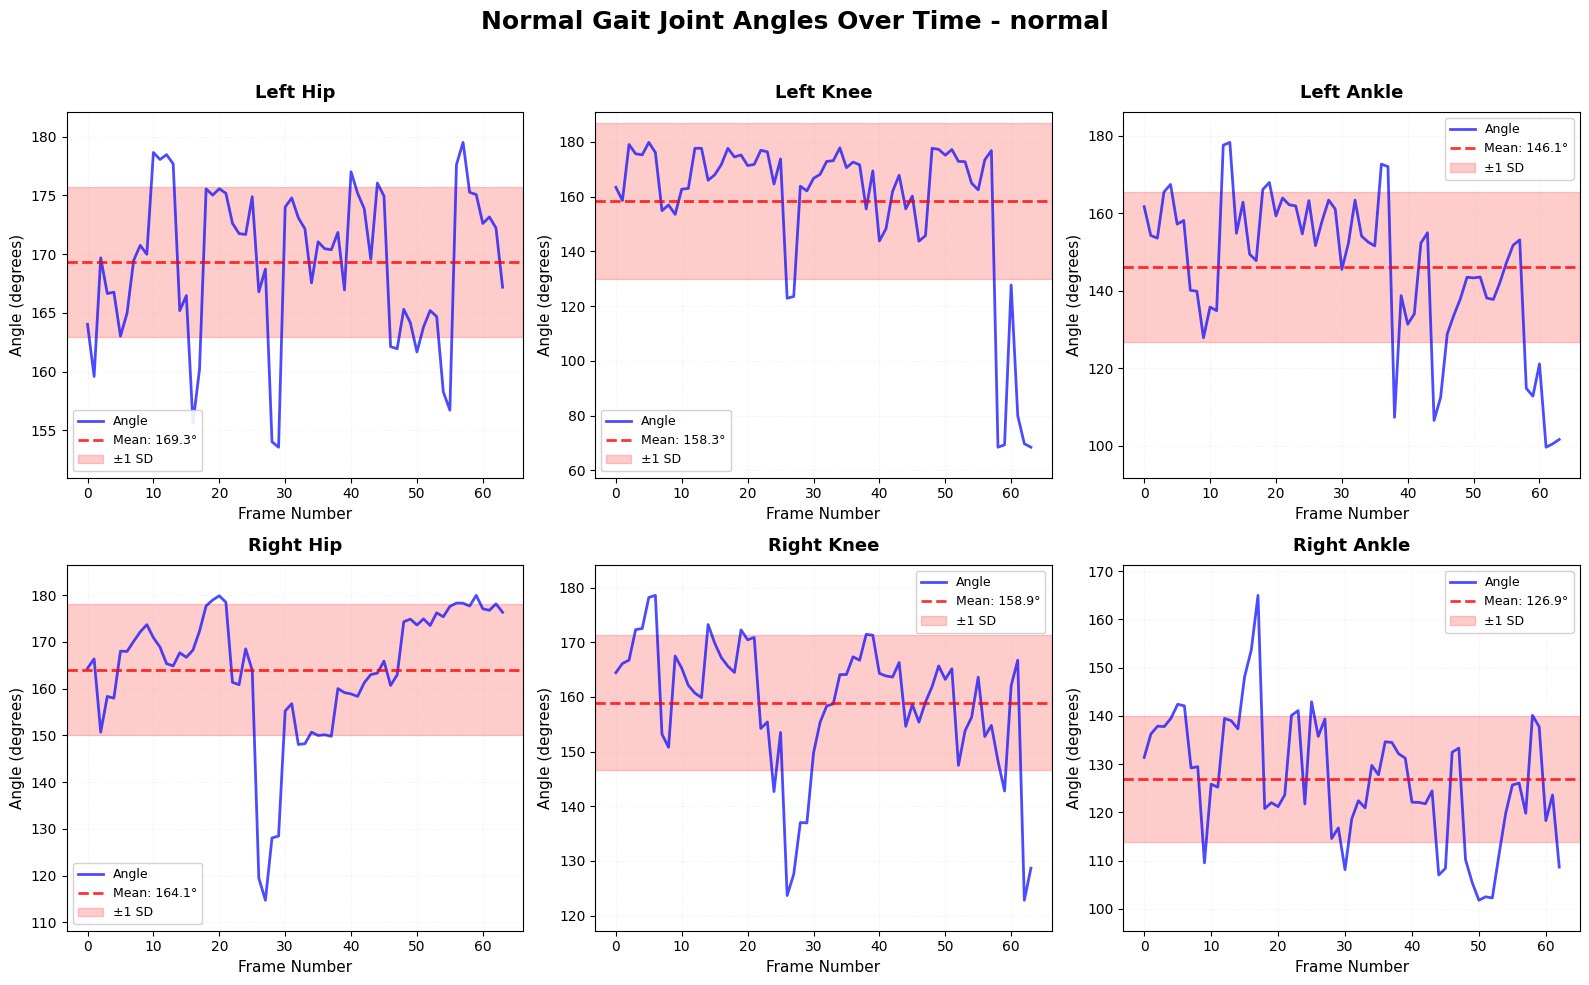


Joint Angle Statistics
Joint               Mean      Std      Min      Max    Range
----------------------------------------------------------------------
left_hip           169.3°     6.4°   153.6°   179.5°    25.9°
left_knee          158.3°    28.4°    68.4°   179.8°   111.4°
left_ankle         146.1°    19.3°    99.6°   178.3°    78.7°
right_hip          164.1°    14.0°   114.8°   180.0°    65.2°
right_knee         158.9°    12.3°   122.8°   178.6°    55.8°
right_ankle        126.9°    13.1°   101.8°   165.0°    63.2°



In [22]:
plot_joint_angles_statistics("Normal Gait", normal_joint_angles)


Visualizing joint angles for Stroke Gait...
Number of frames with joint angles: 166


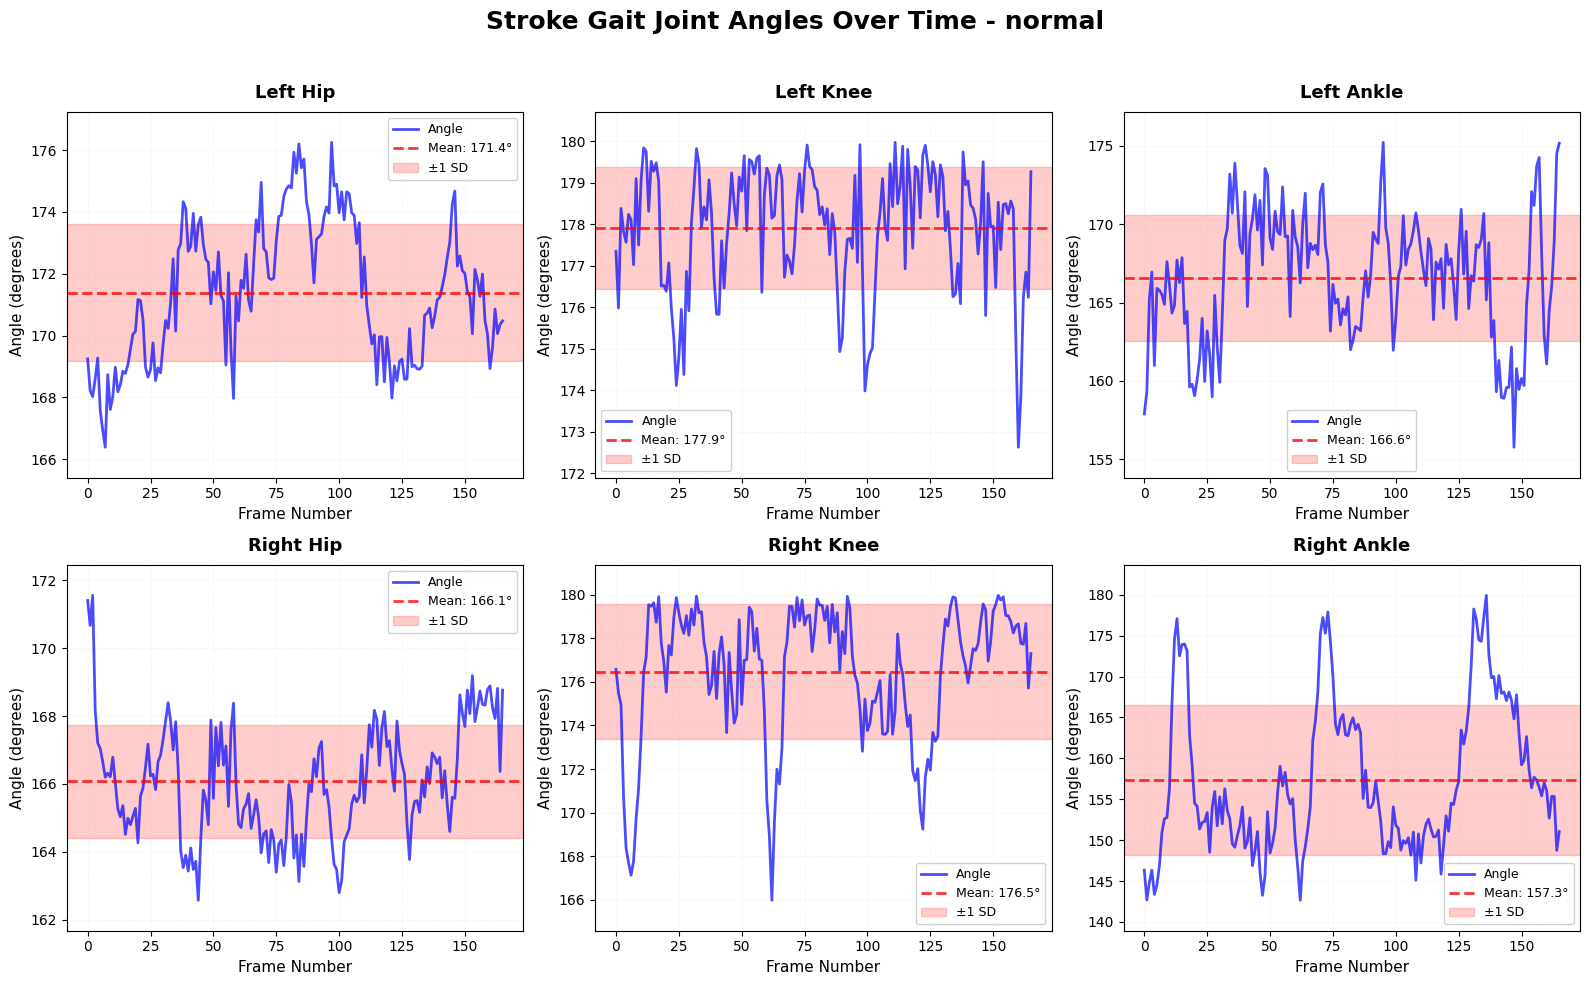


Joint Angle Statistics
Joint               Mean      Std      Min      Max    Range
----------------------------------------------------------------------
left_hip           171.4°     2.2°   166.4°   176.3°     9.9°
left_knee          177.9°     1.5°   172.6°   180.0°     7.4°
left_ankle         166.6°     4.0°   155.8°   175.2°    19.5°
right_hip          166.1°     1.7°   162.6°   171.6°     9.0°
right_knee         176.5°     3.1°   166.0°   180.0°    14.0°
right_ankle        157.3°     9.1°   142.7°   179.9°    37.3°



In [23]:
plot_joint_angles_statistics("Stroke Gait", stroke_joint_angles)


Visualizing joint angles for Parkinsons Gait...
Number of frames with joint angles: 81


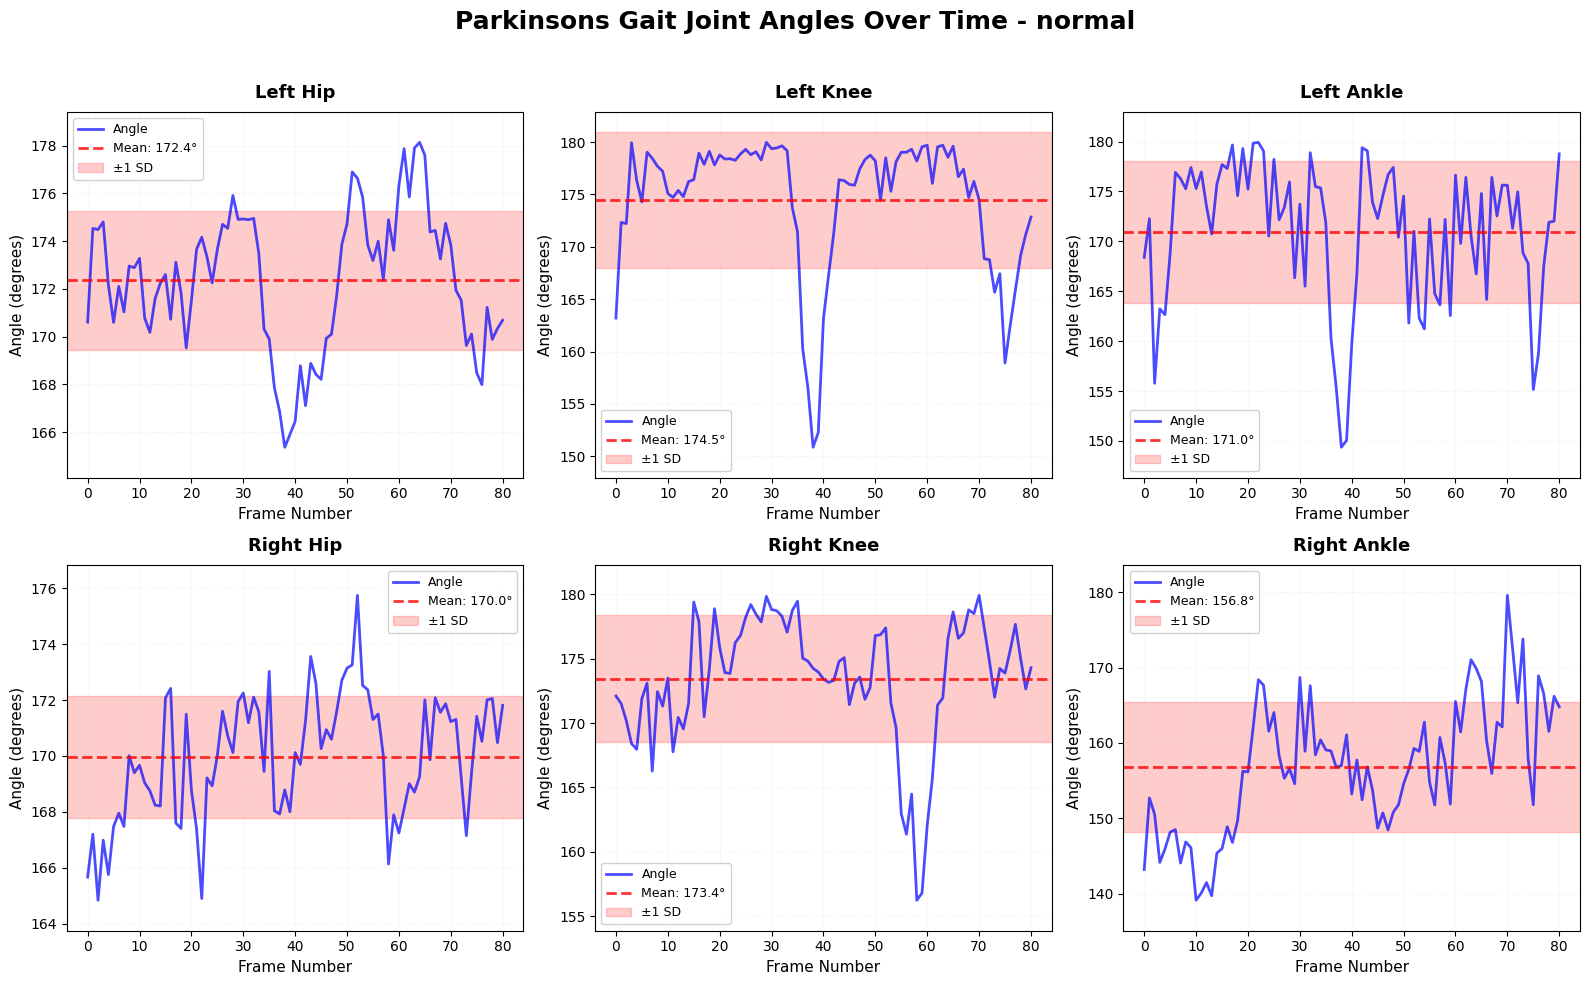


Joint Angle Statistics
Joint               Mean      Std      Min      Max    Range
----------------------------------------------------------------------
left_hip           172.4°     2.9°   165.4°   178.1°    12.8°
left_knee          174.5°     6.5°   150.9°   180.0°    29.1°
left_ankle         171.0°     7.1°   149.4°   179.9°    30.6°
right_hip          170.0°     2.2°   164.8°   175.7°    10.9°
right_knee         173.4°     4.9°   156.3°   179.9°    23.6°
right_ankle        156.8°     8.6°   139.1°   179.6°    40.5°



In [24]:
plot_joint_angles_statistics("Parkinsons Gait", parkinsons_joint_angles)

## 5.  Extract Features for Classification

In [25]:
from ambient.classification.knn_classifier import (
    KNNGaitClassifier,
    KNNClassifierConfig,
    GaitFeatureVector
)

In [26]:
# Create feature vector
feature_vector = GaitFeatureVector.from_joint_angles(
    normal_joint_angles,
    sample_id=normal_sid,
    condition_label="normal"
)

print("Feature Vector:")
print(f"  Sample ID: {feature_vector.sample_id}")
print(f"  Condition: {feature_vector.condition_label}")
print(f"\nFeatures:")
for name in GaitFeatureVector.get_feature_names():
    value = getattr(feature_vector, name)
    print(f"  {name:20s}: {value:7.2f}")

Feature Vector:
  Sample ID: cljo30lnz001q3n6lopfty7q5
  Condition: normal

Features:
  left_hip_mean       :  169.31
  left_knee_mean      :  158.35
  left_ankle_mean     :  146.13
  right_hip_mean      :  164.07
  right_knee_mean     :  158.93
  right_ankle_mean    :  126.87
  hip_asymmetry       :    5.24
  knee_asymmetry      :    0.58
  ankle_asymmetry     :   19.25
  left_hip_range      :   25.95
  left_knee_range     :  111.44
  left_ankle_range    :   78.70
  right_hip_range     :   65.20
  right_knee_range    :   55.75
  right_ankle_range   :   63.18


In [27]:
def extract_all_features(condition_paths, video_base_path):
    """Extract features from all condition directories."""
    all_features = []
    condition_counts = defaultdict(int)
    gavd_loader = GAVDDataLoader()
    
    for condition_path in condition_paths:
        condition_name = condition_path.name
        print(f"\nProcessing: {condition_name}")
        
        for csv_path in condition_path.glob("*.csv"):
            try:
                df = gavd_loader.load_gavd_data(str(csv_path))
                sequences = gavd_loader.organize_by_sequence(df)
                
                for seq_id in sequences:
                    try:
                        sequence_df = sequences[seq_id]
                        
                        # Extract keypoints
                        extractor = SequenceKeypointExtractor()
                        keypoints_array = extractor.extract_from_sequence(
                            sequence_df,
                            video_base_path=video_base_path,
                            verbose=False
                        )
                        
                        if not keypoints_array:
                            continue
                        
                        # Calculate joint angles
                        joint_angles = get_joint_angles(
                            keypoints_array=keypoints_array,
                            keypoint_format="BLAZEPOSE_33",
                            fps=30.0,
                            confidence_threshold=0.3,
                            sequence_id=seq_id
                        )
                        
                        if len(joint_angles.frames) == 0:
                            continue
                        
                        # Create feature vector
                        feature_vector = GaitFeatureVector.from_joint_angles(
                            joint_angles,
                            sample_id=seq_id,
                            condition_label=condition_name
                        )
                        
                        all_features.append(feature_vector)
                        condition_counts[condition_name] += 1
                        print(f"  ✓ {seq_id}")
                    
                    except Exception as e:
                        print(f"  ✗ {seq_id}: {e}")
            
            except Exception as e:
                print(f"  Error processing {csv_path.name}: {e}")
    
    return all_features, dict(condition_counts)

In [28]:
# Extract all features
###### all_features, condition_counts = extract_all_features(condition_paths, video_base_path)

# print(f"\n{'='*60}")
# print(f"Total features extracted: {len(all_features)}")
# print(f"\nCondition distribution:")
# for condition, count in sorted(condition_counts.items()):
#     print(f"  {condition:15s}: {count:3d} samples")

### Save and Load Feature Data

Let's create functions to save and load the extracted features to avoid re-extracting them every time.

In [29]:
from ambient.utils.features import save_features, load_features

# save_path = save_features(all_features, condition_counts)

# print(f"\nFeatures saved to: {save_path}")

### Load Previously Extracted Features

To load previously saved features instead of re-extracting them, uncomment and run the cell below:

In [30]:
all_features, condition_counts = load_features()
print(f"\n{'='*60}")
print(f"Total features loaded: {len(all_features)}")
print(f"\nCondition distribution:")
for condition, count in sorted(condition_counts.items()):
     print(f"  {condition:15s}: {count:3d} samples")

✓ Features loaded successfully from: /Users/pmui/dev/alex/alexpose/experiments/exp4/extracted_features.pkl
  Saved on: 2026-01-21T23:55:10.611492
  Total features: 33
  Conditions: ['stroke', 'parkinsons', 'normal']

Total features loaded: 33

Condition distribution:
  normal         :  12 samples
  parkinsons     :   9 samples
  stroke         :  12 samples


## 5. Visualize Feature Distributions

Let's visualize how features differ across conditions.

In [31]:
# Convert to DataFrame for visualization
feature_data = []
for fv in all_features:
    row = {name: getattr(fv, name) for name in GaitFeatureVector.get_feature_names()}
    row['condition'] = fv.condition_label
    feature_data.append(row)

df_features = pd.DataFrame(feature_data)
print(df_features.head())

   left_hip_mean  left_knee_mean  left_ankle_mean  right_hip_mean  \
0     171.386025      177.908180       166.568341      166.074539   
1     156.141769      153.552486       120.422077      156.890067   
2     155.569054      156.089243       103.845949      161.497096   
3     154.076441      153.956202       129.569083      161.561175   
4      76.979710       72.227276       126.784871       90.234718   

   right_knee_mean  right_ankle_mean  hip_asymmetry  knee_asymmetry  \
0       176.462693        157.345647       5.311486        1.445487   
1       160.451742        137.284817       0.748298        6.899256   
2       145.857837        104.170671       5.928043       10.231406   
3       159.928060        144.689124       7.484734        5.971858   
4        65.059949        140.385344      13.255008        7.167327   

   ankle_asymmetry  left_hip_range  left_knee_range  left_ankle_range  \
0         9.222694        9.872563         7.353112         19.466260   
1        16.

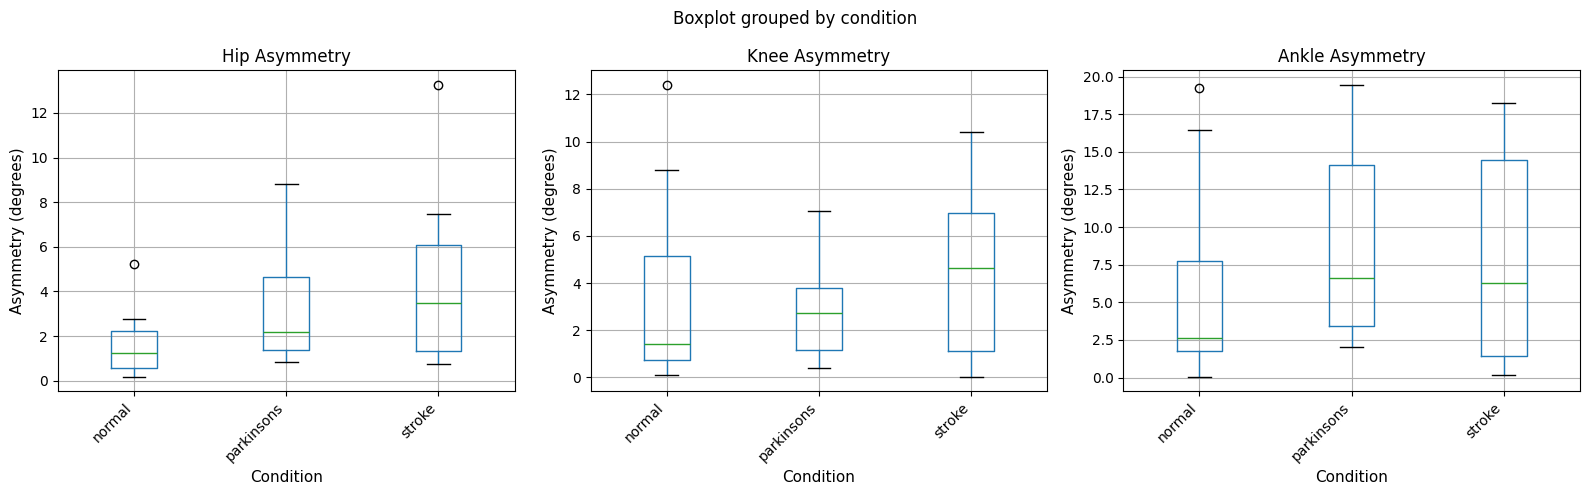

In [32]:
# Plot asymmetry features by condition
if len(all_features) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Asymmetry Features by Condition", fontsize=16, fontweight='bold')
    
    asymmetry_features = ['hip_asymmetry', 'knee_asymmetry', 'ankle_asymmetry']
    
    for idx, feature in enumerate(asymmetry_features):
        ax = axes[idx]
        df_features.boxplot(column=feature, by='condition', ax=ax)
        ax.set_title(feature.replace('_', ' ').title(), fontsize=12)
        ax.set_xlabel('Condition', fontsize=11)
        ax.set_ylabel('Asymmetry (degrees)', fontsize=11)
        plt.sca(ax)
        plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
else:
    print("No features to visualize")

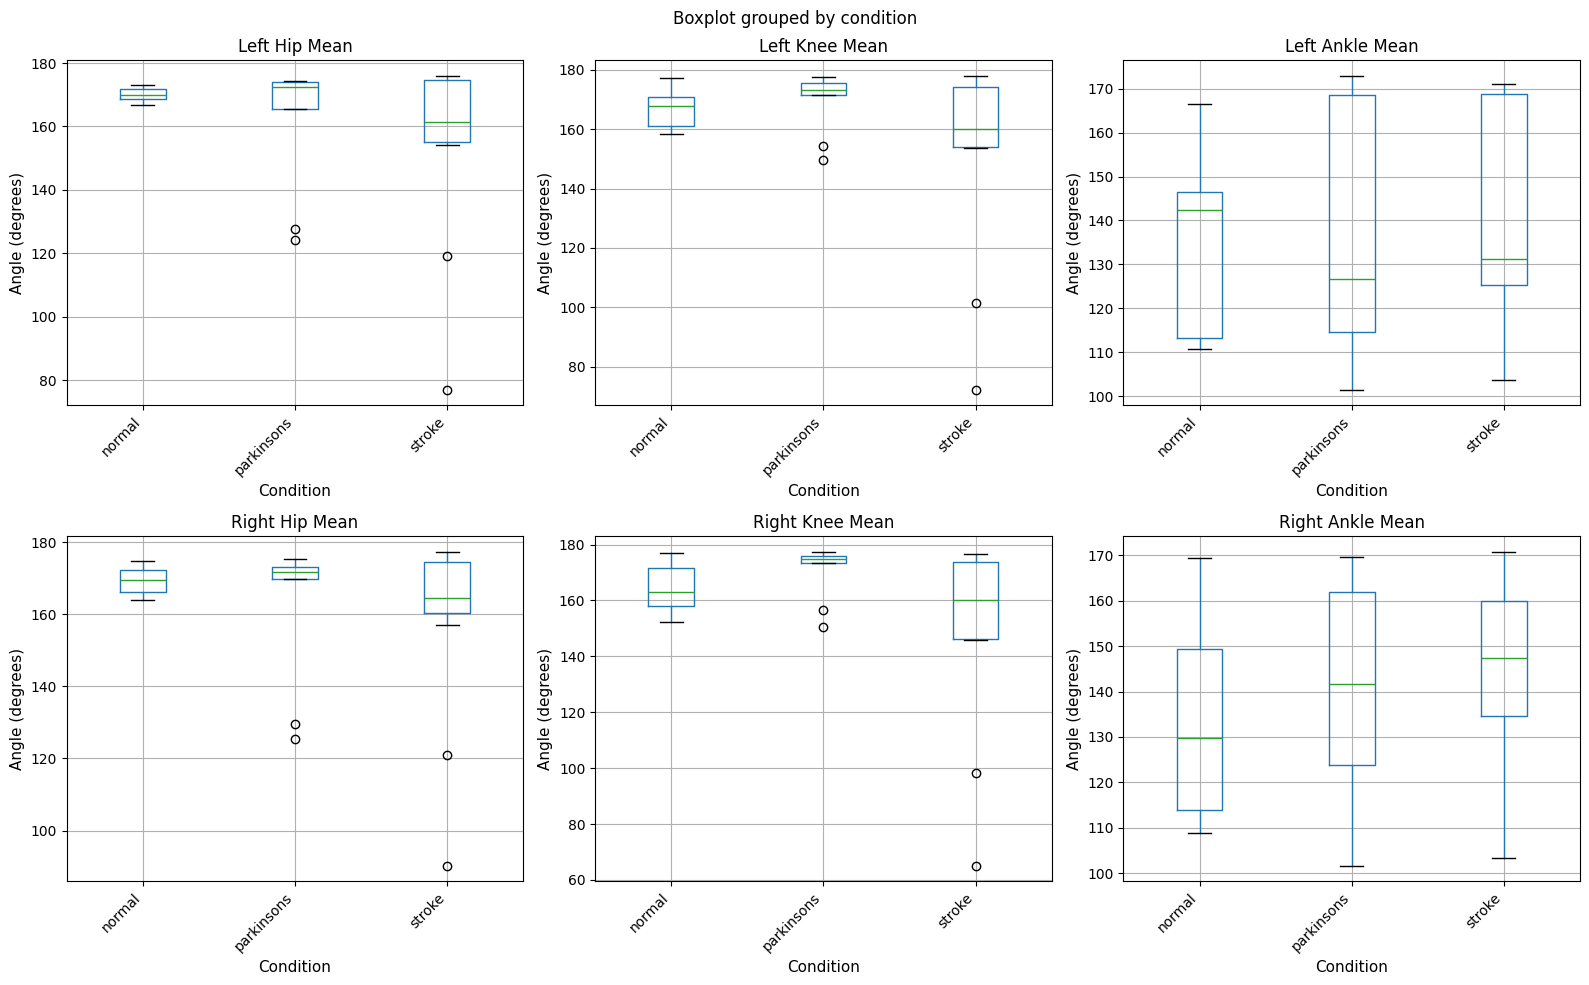

In [33]:
# Plot mean joint angles by condition
if len(all_features) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle("Mean Joint Angles by Condition", fontsize=16, fontweight='bold')
    
    angle_features = [
        'left_hip_mean', 'left_knee_mean', 'left_ankle_mean',
        'right_hip_mean', 'right_knee_mean', 'right_ankle_mean'
    ]
    
    for idx, feature in enumerate(angle_features):
        ax = axes[idx // 3, idx % 3]
        df_features.boxplot(column=feature, by='condition', ax=ax)
        ax.set_title(feature.replace('_', ' ').title(), fontsize=12)
        ax.set_xlabel('Condition', fontsize=11)
        ax.set_ylabel('Angle (degrees)', fontsize=11)
        plt.sca(ax)
        plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
else:
    print("No features to visualize")

## 6. Train & Eval KNN Classifier

Now let's train a KNN classifier on our extracted features.

In [34]:
# Split into train/test (80/20)
np.random.seed(42)
indices = np.random.permutation(len(all_features))
split_idx = int(0.8 * len(all_features))

train_indices = indices[:split_idx]
test_indices = indices[split_idx:]

train_features = [all_features[i] for i in train_indices]
test_features = [all_features[i] for i in test_indices]

print(f"Training samples: {len(train_features)}")
print(f"Test samples: {len(test_features)}")

Training samples: 26
Test samples: 7


In [35]:

# Configure and train classifier
config = KNNClassifierConfig(
    n_neighbors=5,
    weights="distance",
    metric="euclidean",
    normalize_features=True
)

classifier = KNNGaitClassifier(config=config)
metrics = classifier.train(train_features, validate=True)

print("\nTraining Results:")
print(f"  Training Accuracy: {metrics['train_accuracy']:.3f}")
if 'cv_mean_accuracy' in metrics:
    print(f"  CV Accuracy: {metrics['cv_mean_accuracy']:.3f} ± {metrics['cv_std_accuracy']:.3f}")
print(f"  Classes: {metrics['classes']}")

2026-01-22 12:17:38.186 | INFO     | ambient.classification.knn_classifier:__init__:238 - KNN classifier initialized with k=5
2026-01-22 12:17:38.187 | INFO     | ambient.classification.knn_classifier:train:267 - Training KNN classifier with 26 samples
2026-01-22 12:17:38.187 | INFO     | ambient.classification.knn_classifier:train:268 - Feature shape: (26, 15)
2026-01-22 12:17:38.187 | INFO     | ambient.classification.knn_classifier:train:269 - Classes: ['normal' 'parkinsons' 'stroke']
2026-01-22 12:17:38.188 | INFO     | ambient.classification.knn_classifier:train:274 - Features normalized using StandardScaler
2026-01-22 12:17:38.195 | INFO     | ambient.classification.knn_classifier:train:298 - Cross-validation accuracy: 0.580 ± 0.133
2026-01-22 12:17:38.196 | INFO     | ambient.classification.knn_classifier:train:302 - Training complete. Accuracy: 1.000



Training Results:
  Training Accuracy: 1.000
  CV Accuracy: 0.580 ± 0.133
  Classes: [np.str_('normal'), np.str_('parkinsons'), np.str_('stroke')]


In [36]:
# Evaluate on test set
eval_metrics = classifier.evaluate(test_features)

print(f"Test Accuracy: {eval_metrics['accuracy']:.3f}")
print(f"\nClassification Report:")
report = eval_metrics['classification_report']
for class_name in eval_metrics['classes']:
    if class_name in report:
        cm = report[class_name]
        print(f"\n{class_name}:")
        print(f"  Precision: {cm['precision']:.3f}")
        print(f"  Recall: {cm['recall']:.3f}")
        print(f"  F1-Score: {cm['f1-score']:.3f}")

2026-01-22 12:17:38.203 | INFO     | ambient.classification.knn_classifier:evaluate:458 - Test accuracy: 0.429


Test Accuracy: 0.429

Classification Report:

normal:
  Precision: 0.400
  Recall: 1.000
  F1-Score: 0.571

parkinsons:
  Precision: 0.000
  Recall: 0.000
  F1-Score: 0.000

stroke:
  Precision: 0.500
  Recall: 0.333
  F1-Score: 0.400


## 7.  Train & Eval Random Forest Classifier

In [37]:
from ambient.classification.rf_classifier import RFClassifierConfig, RFGaitClassifier

# Configure and train Random Forest classifier
# Random Forest is an ensemble learning method that uses multiple decision trees
# to improve classification accuracy and reduce overfitting.
#
# Key parameters:
#   - n_estimators: Number of trees in the forest (more trees = better accuracy but slower)
#   - max_depth: Maximum depth of each tree (None = unlimited, prevents overfitting)
#   - min_samples_split: Minimum samples required to split a node (higher = more conservative)
#   - min_samples_leaf: Minimum samples required at leaf node (higher = smoother decision boundaries)
#   - max_features: Number of features to consider for best split ('sqrt' is recommended)
#   - class_weight: 'balanced' automatically adjusts for imbalanced datasets
#   - normalize_features: Standardize features to zero mean and unit variance
#   - random_state: Seed for reproducibility
config = RFClassifierConfig(
    n_estimators=100,           # Number of decision trees in the forest
    max_depth=None,             # No limit on tree depth (trees grow until pure)
    min_samples_split=2,        # Minimum samples to split an internal node
    min_samples_leaf=1,         # Minimum samples required at a leaf node
    max_features="sqrt",        # Use sqrt(n_features) for each split
    bootstrap=True,             # Use bootstrap sampling for building trees
    class_weight="balanced",    # Handle imbalanced classes automatically
    normalize_features=True,    # Standardize features before training
    random_state=42             # For reproducible results
)

# Initialize and train the classifier
classifier = RFGaitClassifier(config=config)
metrics = classifier.train(train_features, validate=True)

# Display training results
print("\n" + "="*70)
print("RANDOM FOREST TRAINING RESULTS")
print("="*70)
print(f"Training Accuracy:     {metrics['train_accuracy']:.3f}")
print(f"Number of Samples:     {metrics['n_samples']}")
print(f"Number of Features:    {metrics['n_features']}")
print(f"Number of Trees:       {metrics['n_estimators']}")
print(f"Classes:               {metrics['classes']}")

# Display cross-validation results if available
if 'cv_mean_accuracy' in metrics:
    print(f"\nCross-Validation Results:")
    print(f"  Mean Accuracy:       {metrics['cv_mean_accuracy']:.3f}")
    print(f"  Std Deviation:       {metrics['cv_std_accuracy']:.3f}")

# Display class distribution
if 'class_distribution' in metrics:
    print(f"\nClass Distribution:")
    for cls, count in metrics['class_distribution'].items():
        print(f"  {cls:15s}: {count:3d} samples")

# Display top 5 most important features
print(f"\nTop 5 Most Important Features:")
for feat_info in metrics['feature_importances'][:5]:
    print(f"  {feat_info['rank']}. {feat_info['feature']:20s}: {feat_info['importance']:.4f}")
print("="*70)

2026-01-22 12:17:38.209 | INFO     | ambient.classification.rf_classifier:__init__:141 - Random Forest classifier initialized with 100 trees
2026-01-22 12:17:38.209 | INFO     | ambient.classification.rf_classifier:train:180 - Training Random Forest classifier with 26 samples
2026-01-22 12:17:38.209 | INFO     | ambient.classification.rf_classifier:train:181 - Feature shape: (26, 15)
2026-01-22 12:17:38.210 | INFO     | ambient.classification.rf_classifier:train:182 - Classes: ['normal' 'parkinsons' 'stroke']
2026-01-22 12:17:38.210 | INFO     | ambient.classification.rf_classifier:train:187 - Class distribution: {np.str_('normal'): np.int64(10), np.str_('parkinsons'): np.int64(7), np.str_('stroke'): np.int64(9)}
2026-01-22 12:17:38.210 | INFO     | ambient.classification.rf_classifier:train:192 - Features normalized using StandardScaler
2026-01-22 12:17:40.616 | INFO     | ambient.classification.rf_classifier:train:221 - Cross-validation accuracy: 0.573 ± 0.155
2026-01-22 12:17:40.617


RANDOM FOREST TRAINING RESULTS
Training Accuracy:     1.000
Number of Samples:     26
Number of Features:    15
Number of Trees:       100
Classes:               [np.str_('normal'), np.str_('parkinsons'), np.str_('stroke')]

Cross-Validation Results:
  Mean Accuracy:       0.573
  Std Deviation:       0.155

Class Distribution:
  normal         :  10 samples
  parkinsons     :   7 samples
  stroke         :   9 samples

Top 5 Most Important Features:
  1. right_hip_range     : 0.0973
  2. left_knee_mean      : 0.0810
  3. left_hip_mean       : 0.0794
  4. hip_asymmetry       : 0.0773
  5. right_knee_mean     : 0.0761


In [38]:
# Evaluate on test set
eval_metrics = classifier.evaluate(test_features)

print(f"Test Accuracy: {eval_metrics['accuracy']:.3f}")
print(f"\nClassification Report:")
report = eval_metrics['classification_report']
for class_name in eval_metrics['classes']:
    if class_name in report:
        cm = report[class_name]
        print(f"\n{class_name}:")
        print(f"  Precision: {cm['precision']:.3f}")
        print(f"  Recall: {cm['recall']:.3f}")
        print(f"  F1-Score: {cm['f1-score']:.3f}")

2026-01-22 12:17:40.645 | INFO     | ambient.classification.rf_classifier:evaluate:447 - Test accuracy: 0.571
2026-01-22 12:17:40.646 | INFO     | ambient.classification.rf_classifier:evaluate:448 - Test F1 score: 0.444


Test Accuracy: 0.571

Classification Report:

normal:
  Precision: 0.500
  Recall: 1.000
  F1-Score: 0.667

parkinsons:
  Precision: 0.000
  Recall: 0.000
  F1-Score: 0.000

stroke:
  Precision: 0.667
  Recall: 0.667
  F1-Score: 0.667


## 8.  Train & Eval an SVM Classifier

In [39]:
from ambient.classification.svm_classifier import (
    SVMGaitClassifier,
    SVMClassifierConfig
)

# Configure and train SVM classifier
# Support Vector Machine (SVM) is a powerful classifier that finds optimal
# decision boundaries (hyperplanes) in high-dimensional feature spaces.
#
# Key parameters:
#   - kernel: Type of kernel function ('rbf', 'linear', 'poly', 'sigmoid')
#   - C: Regularization parameter (higher = less regularization, may overfit)
#   - gamma: Kernel coefficient for 'rbf', 'poly', 'sigmoid' ('scale' is recommended)
#   - class_weight: 'balanced' automatically adjusts for imbalanced datasets
#   - probability: Enable probability estimates for predictions
#   - random_state: Seed for reproducibility
svm_config = SVMClassifierConfig(
    kernel='rbf',               # Radial Basis Function kernel for non-linear patterns
    C=10.0,                     # Regularization parameter
    gamma='scale',              # Kernel coefficient (1 / (n_features * X.var()))
    class_weight='balanced',    # Handle imbalanced classes automatically
    probability=True,           # Enable probability estimates
    random_state=42             # For reproducible results
)

# Initialize and train the SVM classifier
svm_classifier = SVMGaitClassifier(svm_config)
print("✓ SVM classifier created")

2026-01-22 12:17:40.656 | INFO     | ambient.classification.svm_classifier:__init__:77 - SVM classifier initialized with rbf kernel, C=10.0


✓ SVM classifier created


In [40]:
# Train SVM classifier
svm_metrics = svm_classifier.train(train_features, validate=True)

# Display training results
print("\n" + "="*70)
print("SVM TRAINING RESULTS")
print("="*70)
print(f"Training Accuracy:     {svm_metrics['train_accuracy']:.3f}")
print(f"Number of Samples:     {svm_metrics['n_samples']}")
print(f"Number of Features:    {svm_metrics['n_features']}")
print(f"Classes:               {svm_metrics['classes']}")

# Display support vector information
if 'n_support_vectors' in svm_metrics:
    print(f"\nSupport Vector Information:")
    print(f"  Total Support Vectors: {svm_metrics['n_support_vectors']}")
    print(f"  Support Vectors per Class:")
    for cls, count in svm_metrics['support_vectors_per_class'].items():
        print(f"    {cls:15s}: {count:3d} vectors")

# Display cross-validation results if available
if 'cv_mean_accuracy' in svm_metrics:
    print(f"\nCross-Validation Results:")
    print(f"  Mean Accuracy:       {svm_metrics['cv_mean_accuracy']:.3f}")
    print(f"  Std Deviation:       {svm_metrics['cv_std_accuracy']:.3f}")

# Display class distribution
if 'class_distribution' in svm_metrics:
    print(f"\nClass Distribution:")
    for cls, count in svm_metrics['class_distribution'].items():
        print(f"  {cls:15s}: {count:3d} samples")

print("="*70)

2026-01-22 12:17:40.662 | INFO     | ambient.classification.base_classifier:train:129 - Training SVMGaitClassifier with 26 samples
2026-01-22 12:17:40.663 | INFO     | ambient.classification.base_classifier:train:130 - Feature shape: (26, 15)
2026-01-22 12:17:40.663 | INFO     | ambient.classification.base_classifier:train:131 - Classes: ['normal' 'parkinsons' 'stroke']
2026-01-22 12:17:40.663 | INFO     | ambient.classification.base_classifier:train:136 - Class distribution: {np.str_('normal'): np.int64(10), np.str_('parkinsons'): np.int64(7), np.str_('stroke'): np.int64(9)}
2026-01-22 12:17:42.420 | INFO     | ambient.classification.base_classifier:train:171 - Cross-validation accuracy: 0.613 ± 0.129
2026-01-22 12:17:42.421 | INFO     | ambient.classification.base_classifier:train:175 - Training complete. Accuracy: 0.962
2026-01-22 12:17:42.421 | INFO     | ambient.classification.svm_classifier:train:126 - Support vectors: 23 total
2026-01-22 12:17:42.421 | INFO     | ambient.classif


SVM TRAINING RESULTS
Training Accuracy:     0.962
Number of Samples:     26
Number of Features:    15
Classes:               [np.str_('normal'), np.str_('parkinsons'), np.str_('stroke')]

Support Vector Information:
  Total Support Vectors: 23
  Support Vectors per Class:
    normal         :   7 vectors
    parkinsons     :   7 vectors
    stroke         :   9 vectors

Cross-Validation Results:
  Mean Accuracy:       0.613
  Std Deviation:       0.129

Class Distribution:
  normal         :  10 samples
  parkinsons     :   7 samples
  stroke         :   9 samples


In [41]:
# Evaluate SVM on test set
svm_eval_metrics = svm_classifier.evaluate(test_features)

print(f"Test Accuracy: {svm_eval_metrics['accuracy']:.3f}")
print(f"\nClassification Report:")
svm_report = svm_eval_metrics['classification_report']
for class_name in svm_eval_metrics['classes']:
    if class_name in svm_report:
        cm = svm_report[class_name]
        print(f"\n{class_name}:")
        print(f"  Precision: {cm['precision']:.3f}")
        print(f"  Recall: {cm['recall']:.3f}")
        print(f"  F1-Score: {cm['f1-score']:.3f}")

2026-01-22 12:17:42.433 | INFO     | ambient.classification.base_classifier:evaluate:289 - Test accuracy: 0.571
2026-01-22 12:17:42.433 | INFO     | ambient.classification.base_classifier:evaluate:290 - Test F1 score: 0.556


Test Accuracy: 0.571

Classification Report:

normal:
  Precision: 0.500
  Recall: 0.500
  F1-Score: 0.500

parkinsons:
  Precision: 0.500
  Recall: 0.500
  F1-Score: 0.500

stroke:
  Precision: 0.667
  Recall: 0.667
  F1-Score: 0.667


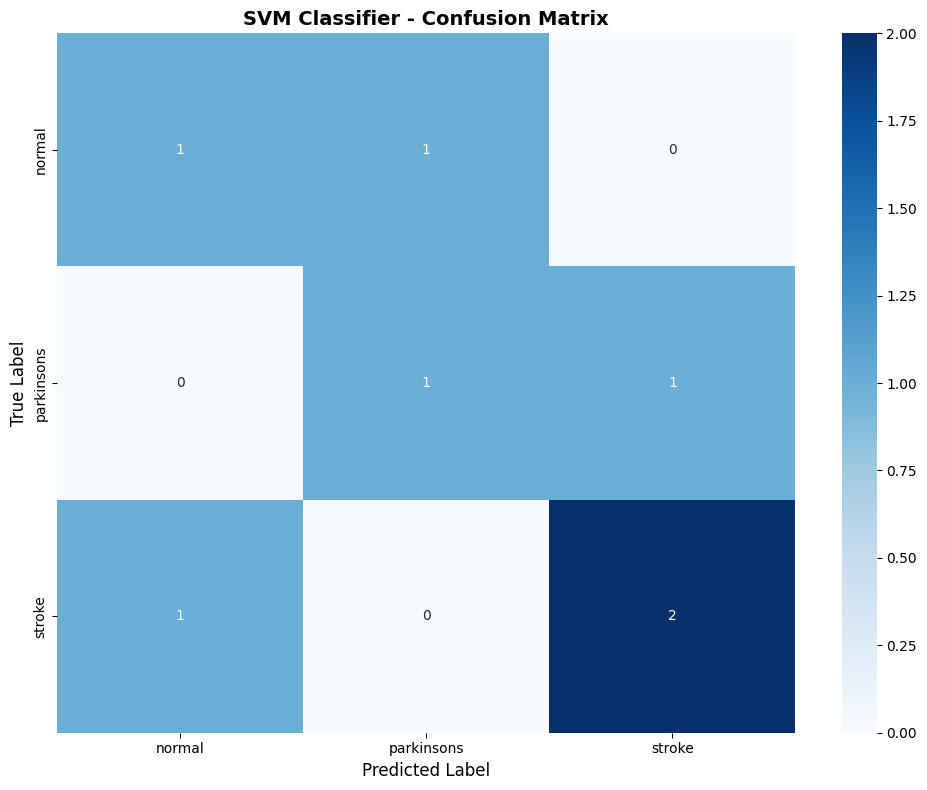


✓ SVM classifier trained and evaluated


In [42]:
# Plot SVM confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(
    svm_eval_metrics['confusion_matrix'],
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=svm_eval_metrics['classes'],
    yticklabels=svm_eval_metrics['classes']
)
plt.title('SVM Classifier - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print("\n✓ SVM classifier trained and evaluated")

## 9.  Train & Eval an XGBoost Classifier

In [43]:
from ambient.classification.xgboost_classifier import (
    XGBoostGaitClassifier,
    XGBoostClassifierConfig
)

# Configure and train XGBoost classifier
# XGBoost (eXtreme Gradient Boosting) is a state-of-the-art gradient boosting
# algorithm that builds trees sequentially, with each tree correcting errors
# from previous trees. Often achieves the best accuracy on structured data.
#
# Key parameters:
#   - n_estimators: Number of boosting rounds (trees to build sequentially)
#   - max_depth: Maximum depth of each tree (lower = less overfitting)
#   - learning_rate: Step size shrinkage (lower = more conservative, needs more trees)
#   - subsample: Fraction of samples used for each tree (< 1.0 prevents overfitting)
#   - colsample_bytree: Fraction of features used for each tree
#   - reg_alpha: L1 regularization term (higher = more conservative)
#   - reg_lambda: L2 regularization term (higher = more conservative)
#   - random_state: Seed for reproducibility
xgb_config = XGBoostClassifierConfig(
    n_estimators=200,           # Number of boosting rounds
    max_depth=5,                # Maximum tree depth (shallower than RF)
    learning_rate=0.1,          # Learning rate (eta)
    subsample=0.8,              # Subsample ratio of training instances
    colsample_bytree=0.8,       # Subsample ratio of features
    reg_alpha=0.1,              # L1 regularization
    reg_lambda=1.0,             # L2 regularization
    min_child_weight=1,         # Minimum sum of instance weight in a child
    gamma=0.0,                  # Minimum loss reduction for split
    normalize_features=True,    # Standardize features before training
    random_state=42             # For reproducible results
)

# Initialize and train the XGBoost classifier
xgb_classifier = XGBoostGaitClassifier(xgb_config)
print("✓ XGBoost classifier created")

2026-01-22 12:17:42.534 | INFO     | ambient.classification.xgboost_classifier:__init__:85 - XGBoost classifier initialized with 200 estimators


✓ XGBoost classifier created


In [44]:
# Train XGBoost classifier
xgb_metrics = xgb_classifier.train(train_features, validate=True)

# Display training results
print("\n" + "="*70)
print("XGBOOST TRAINING RESULTS")
print("="*70)
print(f"Training Accuracy:     {xgb_metrics['train_accuracy']:.3f}")
print(f"Number of Samples:     {xgb_metrics['n_samples']}")
print(f"Number of Features:    {xgb_metrics['n_features']}")
print(f"Number of Estimators:  {xgb_metrics['n_estimators']}")
print(f"Classes:               {xgb_metrics['classes']}")

# Display cross-validation results if available
if 'cv_mean_accuracy' in xgb_metrics:
    print(f"\nCross-Validation Results:")
    print(f"  Mean Accuracy:       {xgb_metrics['cv_mean_accuracy']:.3f}")
    print(f"  Std Deviation:       {xgb_metrics['cv_std_accuracy']:.3f}")

# Display class distribution
if 'class_distribution' in xgb_metrics:
    print(f"\nClass Distribution:")
    for cls, count in xgb_metrics['class_distribution'].items():
        print(f"  {cls:15s}: {count:3d} samples")

# Display top 5 most important features
if 'feature_importances' in xgb_metrics:
    print(f"\nTop 5 Most Important Features:")
    for feat_info in xgb_metrics['feature_importances'][:5]:
        print(f"  {feat_info['rank']}. {feat_info['feature']:20s}: {feat_info['importance']:.4f}")

print("="*70)

2026-01-22 12:17:42.539 | INFO     | ambient.classification.base_classifier:train:129 - Training XGBoostGaitClassifier with 26 samples
2026-01-22 12:17:42.540 | INFO     | ambient.classification.base_classifier:train:130 - Feature shape: (26, 15)
2026-01-22 12:17:42.540 | INFO     | ambient.classification.base_classifier:train:131 - Classes: ['normal' 'parkinsons' 'stroke']
2026-01-22 12:17:42.541 | INFO     | ambient.classification.base_classifier:train:136 - Class distribution: {np.str_('normal'): np.int64(10), np.str_('parkinsons'): np.int64(7), np.str_('stroke'): np.int64(9)}
2026-01-22 12:17:44.236 | INFO     | ambient.classification.base_classifier:train:171 - Cross-validation accuracy: 0.567 ± 0.240
2026-01-22 12:17:44.237 | INFO     | ambient.classification.base_classifier:train:175 - Training complete. Accuracy: 1.000
2026-01-22 12:17:44.238 | INFO     | ambient.classification.xgboost_classifier:train:142 - Top 5 important features:
2026-01-22 12:17:44.238 | INFO     | ambient


XGBOOST TRAINING RESULTS
Training Accuracy:     1.000
Number of Samples:     26
Number of Features:    15
Number of Estimators:  200
Classes:               [np.str_('normal'), np.str_('parkinsons'), np.str_('stroke')]

Cross-Validation Results:
  Mean Accuracy:       0.567
  Std Deviation:       0.240

Class Distribution:
  normal         :  10 samples
  parkinsons     :   7 samples
  stroke         :   9 samples

Top 5 Most Important Features:
  1. left_hip_mean       : 0.1608
  2. right_ankle_mean    : 0.1001
  3. left_knee_range     : 0.0980
  4. left_ankle_mean     : 0.0831
  5. left_hip_range      : 0.0712


In [45]:
# Evaluate XGBoost on test set
xgb_eval_metrics = xgb_classifier.evaluate(test_features)

print(f"Test Accuracy: {xgb_eval_metrics['accuracy']:.3f}")
print(f"\nClassification Report:")
xgb_report = xgb_eval_metrics['classification_report']
for class_name in xgb_eval_metrics['classes']:
    if class_name in xgb_report:
        cm = xgb_report[class_name]
        print(f"\n{class_name}:")
        print(f"  Precision: {cm['precision']:.3f}")
        print(f"  Recall: {cm['recall']:.3f}")
        print(f"  F1-Score: {cm['f1-score']:.3f}")

2026-01-22 12:17:44.250 | INFO     | ambient.classification.base_classifier:evaluate:289 - Test accuracy: 0.571
2026-01-22 12:17:44.250 | INFO     | ambient.classification.base_classifier:evaluate:290 - Test F1 score: 0.444


Test Accuracy: 0.571

Classification Report:

normal:
  Precision: 0.500
  Recall: 1.000
  F1-Score: 0.667

parkinsons:
  Precision: 0.000
  Recall: 0.000
  F1-Score: 0.000

stroke:
  Precision: 0.667
  Recall: 0.667
  F1-Score: 0.667


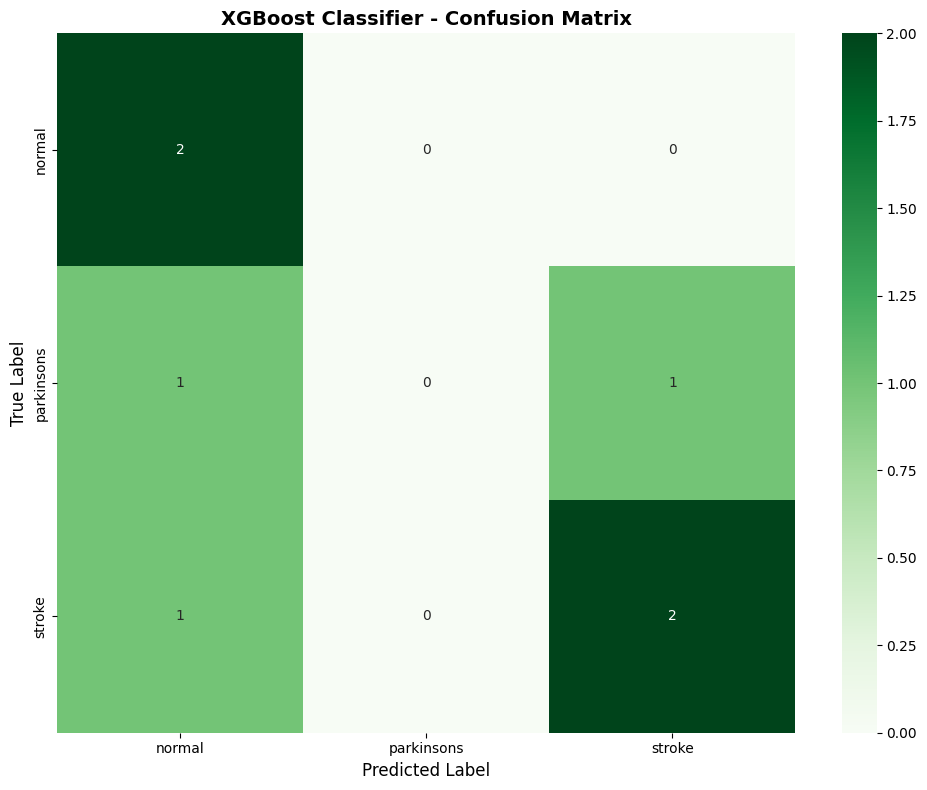


✓ XGBoost classifier trained and evaluated


In [46]:
# Plot XGBoost confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(
    xgb_eval_metrics['confusion_matrix'],
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=xgb_eval_metrics['classes'],
    yticklabels=xgb_eval_metrics['classes']
)
plt.title('XGBoost Classifier - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print("\n✓ XGBoost classifier trained and evaluated")

## 11. Train & Eval Decision Tree Classifier

Decision Trees provide maximum interpretability through a tree structure that can be visualized and converted to simple if-then rules. Each decision node represents a test on a single feature, making the classification process completely transparent.

In [47]:
from ambient.classification.decisiontree_classifier import (
    DecisionTreeGaitClassifier,
    DecisionTreeClassifierConfig
)

# Configure Decision Tree classifier
# Decision Trees create a flowchart-like structure where each internal node
# represents a test on a feature, each branch represents the outcome,
# and each leaf node represents a class label.
#
# Key parameters:
#   - criterion: Function to measure split quality ('gini' or 'entropy')
#   - max_depth: Maximum depth of tree (None = unlimited)
#   - min_samples_split: Minimum samples required to split a node
#   - min_samples_leaf: Minimum samples required at a leaf node
#   - class_weight: 'balanced' handles imbalanced datasets
dt_config = DecisionTreeClassifierConfig(
    criterion='gini',           # Gini impurity for split quality
    max_depth=10,               # Limit depth to prevent overfitting
    min_samples_split=5,        # Require 5 samples to split
    min_samples_leaf=2,         # Require 2 samples per leaf
    class_weight='balanced',    # Handle imbalanced classes
    normalize_features=True,    # Standardize features
    random_state=42             # For reproducibility
)

dt_classifier = DecisionTreeGaitClassifier(dt_config)
print("✓ Decision Tree classifier created")

2026-01-22 12:17:44.323 | INFO     | ambient.classification.decisiontree_classifier:__init__:84 - Decision Tree classifier initialized with gini criterion


✓ Decision Tree classifier created


In [48]:
# Train Decision Tree classifier
dt_metrics = dt_classifier.train(train_features, validate=True)

# Display training results
print("\n" + "="*70)
print("DECISION TREE TRAINING RESULTS")
print("="*70)
print(f"Training Accuracy:     {dt_metrics['train_accuracy']:.3f}")
print(f"Number of Samples:     {dt_metrics['n_samples']}")
print(f"Number of Features:    {dt_metrics['n_features']}")
print(f"Tree Depth:            {dt_metrics['tree_depth']}")
print(f"Number of Leaves:      {dt_metrics['n_leaves']}")
print(f"Classes:               {dt_metrics['classes']}")

# Display cross-validation results
if 'cv_mean_accuracy' in dt_metrics:
    print(f"\nCross-Validation Results:")
    print(f"  Mean Accuracy:       {dt_metrics['cv_mean_accuracy']:.3f}")
    print(f"  Std Deviation:       {dt_metrics['cv_std_accuracy']:.3f}")

# Display class distribution
if 'class_distribution' in dt_metrics:
    print(f"\nClass Distribution:")
    for cls, count in dt_metrics['class_distribution'].items():
        print(f"  {cls:15s}: {count:3d} samples")

# Display top 5 most important features
if 'feature_importances' in dt_metrics:
    print(f"\nTop 5 Most Important Features:")
    for feat_info in dt_metrics['feature_importances'][:5]:
        print(f"  {feat_info['rank']}. {feat_info['feature']:20s}: {feat_info['importance']:.4f}")

print("="*70)

2026-01-22 12:17:44.329 | INFO     | ambient.classification.base_classifier:train:129 - Training DecisionTreeGaitClassifier with 26 samples
2026-01-22 12:17:44.329 | INFO     | ambient.classification.base_classifier:train:130 - Feature shape: (26, 15)
2026-01-22 12:17:44.330 | INFO     | ambient.classification.base_classifier:train:131 - Classes: ['normal' 'parkinsons' 'stroke']
2026-01-22 12:17:44.330 | INFO     | ambient.classification.base_classifier:train:136 - Class distribution: {np.str_('normal'): np.int64(10), np.str_('parkinsons'): np.int64(7), np.str_('stroke'): np.int64(9)}
2026-01-22 12:17:45.953 | INFO     | ambient.classification.base_classifier:train:171 - Cross-validation accuracy: 0.500 ± 0.089
2026-01-22 12:17:45.953 | INFO     | ambient.classification.base_classifier:train:175 - Training complete. Accuracy: 0.923
2026-01-22 12:17:45.953 | INFO     | ambient.classification.decisiontree_classifier:train:157 - Tree depth: 4
2026-01-22 12:17:45.954 | INFO     | ambient.c


DECISION TREE TRAINING RESULTS
Training Accuracy:     0.923
Number of Samples:     26
Number of Features:    15
Tree Depth:            4
Number of Leaves:      6
Classes:               [np.str_('normal'), np.str_('parkinsons'), np.str_('stroke')]

Cross-Validation Results:
  Mean Accuracy:       0.500
  Std Deviation:       0.089

Class Distribution:
  normal         :  10 samples
  parkinsons     :   7 samples
  stroke         :   9 samples

Top 5 Most Important Features:
  1. right_hip_mean      : 0.4626
  2. left_ankle_mean     : 0.2095
  3. hip_asymmetry       : 0.1825
  4. right_ankle_mean    : 0.1454
  5. left_hip_mean       : 0.0000


In [49]:
# Evaluate Decision Tree on test set
dt_eval_metrics = dt_classifier.evaluate(test_features)

print(f"Test Accuracy: {dt_eval_metrics['accuracy']:.3f}")
print(f"\nClassification Report:")
dt_report = dt_eval_metrics['classification_report']
for class_name in dt_eval_metrics['classes']:
    if class_name in dt_report:
        cm = dt_report[class_name]
        print(f"\n{class_name}:")
        print(f"  Precision: {cm['precision']:.3f}")
        print(f"  Recall: {cm['recall']:.3f}")
        print(f"  F1-Score: {cm['f1-score']:.3f}")

2026-01-22 12:17:45.965 | INFO     | ambient.classification.base_classifier:evaluate:289 - Test accuracy: 0.286
2026-01-22 12:17:45.966 | INFO     | ambient.classification.base_classifier:evaluate:290 - Test F1 score: 0.267


Test Accuracy: 0.286

Classification Report:

normal:
  Precision: 0.333
  Recall: 0.500
  F1-Score: 0.400

parkinsons:
  Precision: 0.000
  Recall: 0.000
  F1-Score: 0.000

stroke:
  Precision: 0.500
  Recall: 0.333
  F1-Score: 0.400


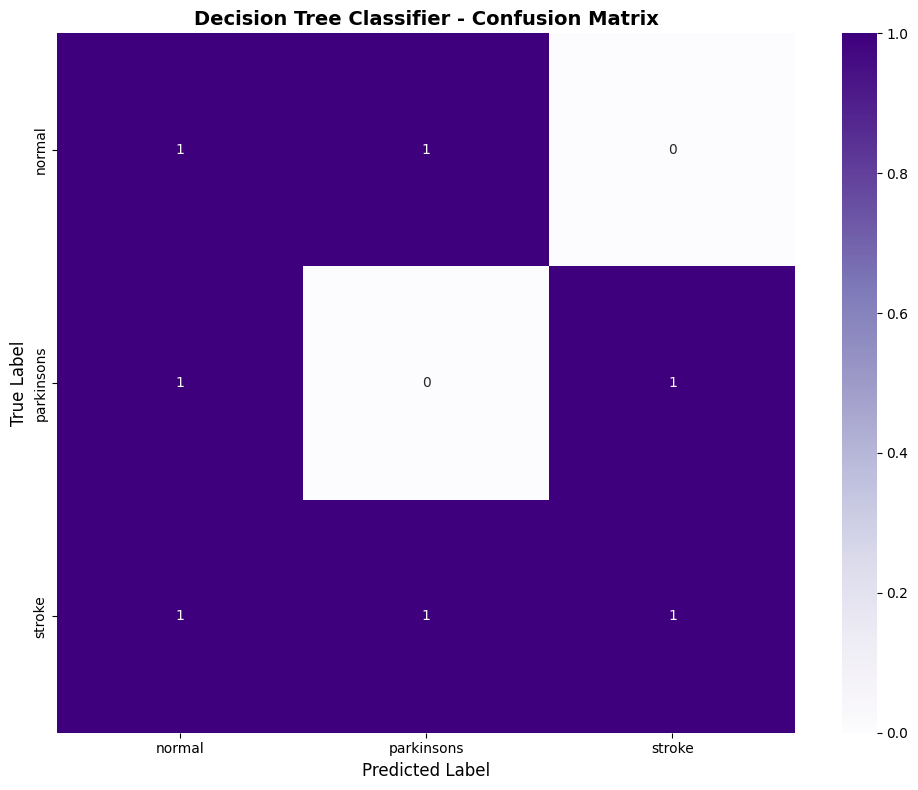


✓ Decision Tree classifier trained and evaluated


In [50]:
# Plot Decision Tree confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(
    dt_eval_metrics['confusion_matrix'],
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=dt_eval_metrics['classes'],
    yticklabels=dt_eval_metrics['classes']
)
plt.title('Decision Tree Classifier - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print("\n✓ Decision Tree classifier trained and evaluated")

## 12. Train & Eval Logistic Regression Classifier

Logistic Regression provides fast, interpretable baseline predictions using linear models. Despite its simplicity, it often performs surprisingly well and serves as an excellent baseline for comparison.

In [51]:
from ambient.classification.logistic_classifier import (
    LogisticGaitClassifier,
    LogisticClassifierConfig
)

# Configure Logistic Regression classifier
# Logistic Regression is a linear model that predicts probabilities
# using a logistic (sigmoid) function. It's fast, interpretable,
# and works well as a baseline.
#
# Key parameters:
#   - penalty: Regularization type ('l1', 'l2', 'elasticnet', 'none')
#   - C: Inverse of regularization strength (smaller = stronger)
#   - solver: Optimization algorithm
#   - max_iter: Maximum iterations for convergence
logistic_config = LogisticClassifierConfig(
    penalty='l2',               # L2 regularization (Ridge)
    C=1.0,                      # Regularization strength
    solver='lbfgs',             # Optimization algorithm
    max_iter=1000,              # Maximum iterations
    class_weight='balanced',    # Handle imbalanced classes
    normalize_features=True,    # Standardize features
    random_state=42             # For reproducibility
)

logistic_classifier = LogisticGaitClassifier(logistic_config)
print("✓ Logistic Regression classifier created")

2026-01-22 12:17:46.031 | INFO     | ambient.classification.logistic_classifier:__init__:81 - Logistic Regression classifier initialized with l2 penalty, C=1.0


✓ Logistic Regression classifier created


In [52]:
# Train Logistic Regression classifier
logistic_metrics = logistic_classifier.train(train_features, validate=True)

# Display training results
print("\n" + "="*70)
print("LOGISTIC REGRESSION TRAINING RESULTS")
print("="*70)
print(f"Training Accuracy:     {logistic_metrics['train_accuracy']:.3f}")
print(f"Number of Samples:     {logistic_metrics['n_samples']}")
print(f"Number of Features:    {logistic_metrics['n_features']}")
print(f"Classes:               {logistic_metrics['classes']}")

# Display cross-validation results
if 'cv_mean_accuracy' in logistic_metrics:
    print(f"\nCross-Validation Results:")
    print(f"  Mean Accuracy:       {logistic_metrics['cv_mean_accuracy']:.3f}")
    print(f"  Std Deviation:       {logistic_metrics['cv_std_accuracy']:.3f}")

# Display class distribution
if 'class_distribution' in logistic_metrics:
    print(f"\nClass Distribution:")
    for cls, count in logistic_metrics['class_distribution'].items():
        print(f"  {cls:15s}: {count:3d} samples")

# Display top features by coefficient
if 'top_features' in logistic_metrics:
    print(f"\nTop 5 Features by Coefficient Magnitude:")
    for i, feat_info in enumerate(logistic_metrics['top_features'], 1):
        print(f"  {i}. {feat_info['feature']:20s}: {feat_info['coefficient']:+.4f}")

print("="*70)

2026-01-22 12:17:46.036 | INFO     | ambient.classification.base_classifier:train:129 - Training LogisticGaitClassifier with 26 samples
2026-01-22 12:17:46.037 | INFO     | ambient.classification.base_classifier:train:130 - Feature shape: (26, 15)
2026-01-22 12:17:46.037 | INFO     | ambient.classification.base_classifier:train:131 - Classes: ['normal' 'parkinsons' 'stroke']
2026-01-22 12:17:46.037 | INFO     | ambient.classification.base_classifier:train:136 - Class distribution: {np.str_('normal'): np.int64(10), np.str_('parkinsons'): np.int64(7), np.str_('stroke'): np.int64(9)}
2026-01-22 12:17:47.814 | INFO     | ambient.classification.base_classifier:train:171 - Cross-validation accuracy: 0.507 ± 0.172
2026-01-22 12:17:47.815 | INFO     | ambient.classification.base_classifier:train:175 - Training complete. Accuracy: 0.923
2026-01-22 12:17:47.816 | INFO     | ambient.classification.logistic_classifier:train:131 - Top 5 features by coefficient magnitude:
2026-01-22 12:17:47.816 | I


LOGISTIC REGRESSION TRAINING RESULTS
Training Accuracy:     0.923
Number of Samples:     26
Number of Features:    15
Classes:               [np.str_('normal'), np.str_('parkinsons'), np.str_('stroke')]

Cross-Validation Results:
  Mean Accuracy:       0.507
  Std Deviation:       0.172

Class Distribution:
  normal         :  10 samples
  parkinsons     :   7 samples
  stroke         :   9 samples

Top 5 Features by Coefficient Magnitude:
  1. left_ankle_range    : +0.0000
  2. right_hip_mean      : -0.0000
  3. right_knee_mean     : +0.0000
  4. right_ankle_mean    : +0.0000
  5. left_hip_mean       : +0.0000


In [53]:
# Evaluate Logistic Regression on test set
logistic_eval_metrics = logistic_classifier.evaluate(test_features)

print(f"Test Accuracy: {logistic_eval_metrics['accuracy']:.3f}")
print(f"\nClassification Report:")
logistic_report = logistic_eval_metrics['classification_report']
for class_name in logistic_eval_metrics['classes']:
    if class_name in logistic_report:
        cm = logistic_report[class_name]
        print(f"\n{class_name}:")
        print(f"  Precision: {cm['precision']:.3f}")
        print(f"  Recall: {cm['recall']:.3f}")
        print(f"  F1-Score: {cm['f1-score']:.3f}")

2026-01-22 12:17:47.829 | INFO     | ambient.classification.base_classifier:evaluate:289 - Test accuracy: 0.429
2026-01-22 12:17:47.829 | INFO     | ambient.classification.base_classifier:evaluate:290 - Test F1 score: 0.433


Test Accuracy: 0.429

Classification Report:

normal:
  Precision: 0.333
  Recall: 0.500
  F1-Score: 0.400

parkinsons:
  Precision: 0.500
  Recall: 0.500
  F1-Score: 0.500

stroke:
  Precision: 0.500
  Recall: 0.333
  F1-Score: 0.400


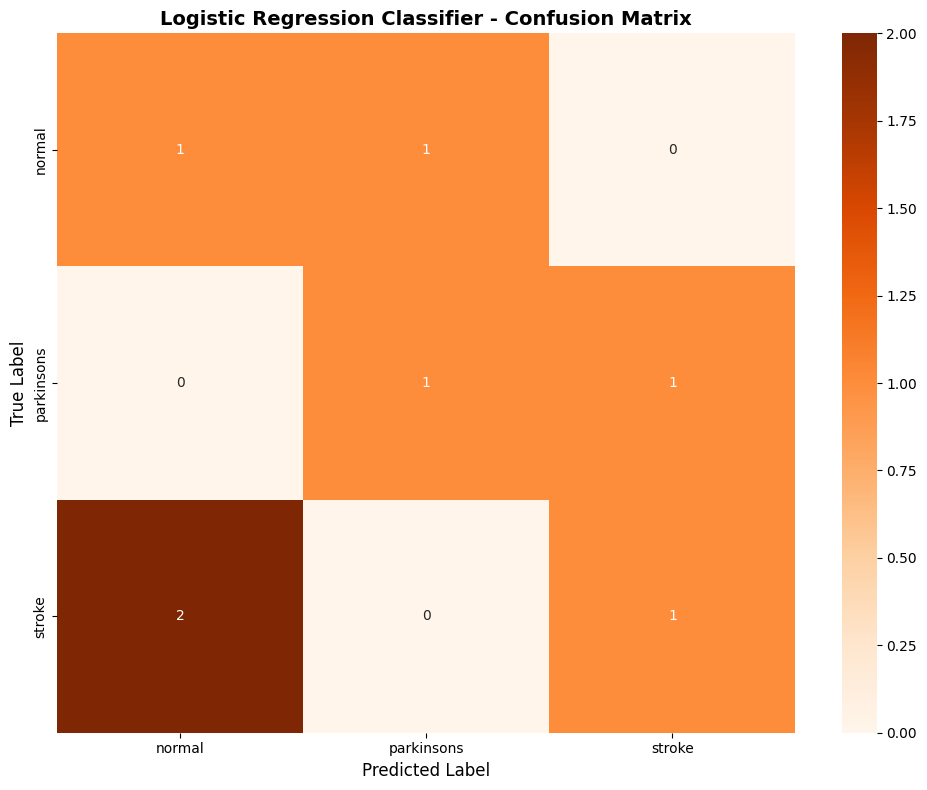


✓ Logistic Regression classifier trained and evaluated


In [54]:
# Plot Logistic Regression confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    logistic_eval_metrics['confusion_matrix'],
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=logistic_eval_metrics['classes'],
    yticklabels=logistic_eval_metrics['classes']
)
plt.title('Logistic Regression Classifier - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print("\n✓ Logistic Regression classifier trained and evaluated")

## 13. Train & Eval MLP Neural Network Classifier

Multi-Layer Perceptron (MLP) is a feedforward neural network that can learn complex non-linear patterns. It's particularly effective when sufficient training data is available.

In [79]:
from ambient.classification.mlp_classifier import (
    MLPGaitClassifier,
    MLPClassifierConfig
)

# Configure MLP classifier
# MLP is a neural network with multiple layers that can learn
# complex non-linear relationships between features.
#
# Key parameters:
#   - hidden_layer_sizes: Tuple of neurons per hidden layer
#   - activation: Activation function ('relu', 'tanh', 'logistic')
#   - solver: Optimization algorithm ('adam', 'sgd', 'lbfgs')
#   - learning_rate_init: Initial learning rate
#   - max_iter: Maximum training iterations
mlp_config = MLPClassifierConfig(
    hidden_layer_sizes=(100, 50),  # Two hidden layers
    activation='relu',              # ReLU activation
    solver='adam',                  # Adam optimizer
    learning_rate_init=0.001,       # Learning rate
    max_iter=300,                   # Maximum iterations
    early_stopping=True,            # Use validation for early stopping
    validation_fraction=0.1,        # 10% for validation
    normalize_features=True,        # Standardize features (important!)
    random_state=42                 # For reproducibility
)

mlp_classifier = MLPGaitClassifier(mlp_config)
print("✓ MLP classifier created")

2026-01-22 12:36:39.961 | INFO     | ambient.classification.mlp_classifier:__init__:93 - MLP classifier initialized with layers (100, 50)


✓ MLP classifier created


In [80]:
# Train MLP classifier
mlp_metrics = mlp_classifier.train(train_features, validate=True)

# Display training results
print("\n" + "="*70)
print("MLP NEURAL NETWORK TRAINING RESULTS")
print("="*70)
print(f"Training Accuracy:     {mlp_metrics['train_accuracy']:.3f}")
print(f"Number of Samples:     {mlp_metrics['n_samples']}")
print(f"Number of Features:    {mlp_metrics['n_features']}")
print(f"Number of Layers:      {mlp_metrics['n_layers']}")
print(f"Training Iterations:   {mlp_metrics['n_iterations']}")
print(f"Final Loss:            {mlp_metrics['final_loss']:.4f}")
print(f"Classes:               {mlp_metrics['classes']}")

# Display cross-validation results
if 'cv_mean_accuracy' in mlp_metrics:
    print(f"\nCross-Validation Results:")
    print(f"  Mean Accuracy:       {mlp_metrics['cv_mean_accuracy']:.3f}")
    print(f"  Std Deviation:       {mlp_metrics['cv_std_accuracy']:.3f}")

# Display validation score if early stopping was used
if 'best_validation_score' in mlp_metrics:
    print(f"\nEarly Stopping:")
    print(f"  Best Validation Score: {mlp_metrics['best_validation_score']:.3f}")

# Display class distribution
if 'class_distribution' in mlp_metrics:
    print(f"\nClass Distribution:")
    for cls, count in mlp_metrics['class_distribution'].items():
        print(f"  {cls:15s}: {count:3d} samples")

print("="*70)

2026-01-22 12:36:40.290 | INFO     | ambient.classification.base_classifier:train:129 - Training MLPGaitClassifier with 26 samples
2026-01-22 12:36:40.291 | INFO     | ambient.classification.base_classifier:train:130 - Feature shape: (26, 15)
2026-01-22 12:36:40.292 | INFO     | ambient.classification.base_classifier:train:131 - Classes: ['normal' 'parkinsons' 'stroke']
2026-01-22 12:36:40.293 | INFO     | ambient.classification.base_classifier:train:136 - Class distribution: {np.str_('normal'): np.int64(10), np.str_('parkinsons'): np.int64(7), np.str_('stroke'): np.int64(9)}
2026-01-22 12:36:41.768 | INFO     | ambient.classification.base_classifier:train:171 - Cross-validation accuracy: 0.460 ± 0.196
2026-01-22 12:36:41.768 | INFO     | ambient.classification.base_classifier:train:175 - Training complete. Accuracy: 0.846
2026-01-22 12:36:41.768 | INFO     | ambient.classification.mlp_classifier:train:145 - Training iterations: 19
2026-01-22 12:36:41.769 | INFO     | ambient.classific


MLP NEURAL NETWORK TRAINING RESULTS
Training Accuracy:     0.846
Number of Samples:     26
Number of Features:    15
Number of Layers:      4
Training Iterations:   19
Final Loss:            0.6538
Classes:               [np.str_('normal'), np.str_('parkinsons'), np.str_('stroke')]

Cross-Validation Results:
  Mean Accuracy:       0.460
  Std Deviation:       0.196

Early Stopping:
  Best Validation Score: 0.667

Class Distribution:
  normal         :  10 samples
  parkinsons     :   7 samples
  stroke         :   9 samples


In [81]:
# Evaluate MLP on test set
mlp_eval_metrics = mlp_classifier.evaluate(test_features)

print(f"Test Accuracy: {mlp_eval_metrics['accuracy']:.3f}")
print(f"\nClassification Report:")
mlp_report = mlp_eval_metrics['classification_report']
for class_name in mlp_eval_metrics['classes']:
    if class_name in mlp_report:
        cm = mlp_report[class_name]
        print(f"\n{class_name}:")
        print(f"  Precision: {cm['precision']:.3f}")
        print(f"  Recall: {cm['recall']:.3f}")
        print(f"  F1-Score: {cm['f1-score']:.3f}")

2026-01-22 12:36:41.779 | INFO     | ambient.classification.base_classifier:evaluate:289 - Test accuracy: 0.714
2026-01-22 12:36:41.779 | INFO     | ambient.classification.base_classifier:evaluate:290 - Test F1 score: 0.675


Test Accuracy: 0.714

Classification Report:

normal:
  Precision: 1.000
  Recall: 0.500
  F1-Score: 0.667

parkinsons:
  Precision: 0.500
  Recall: 0.500
  F1-Score: 0.500

stroke:
  Precision: 0.750
  Recall: 1.000
  F1-Score: 0.857


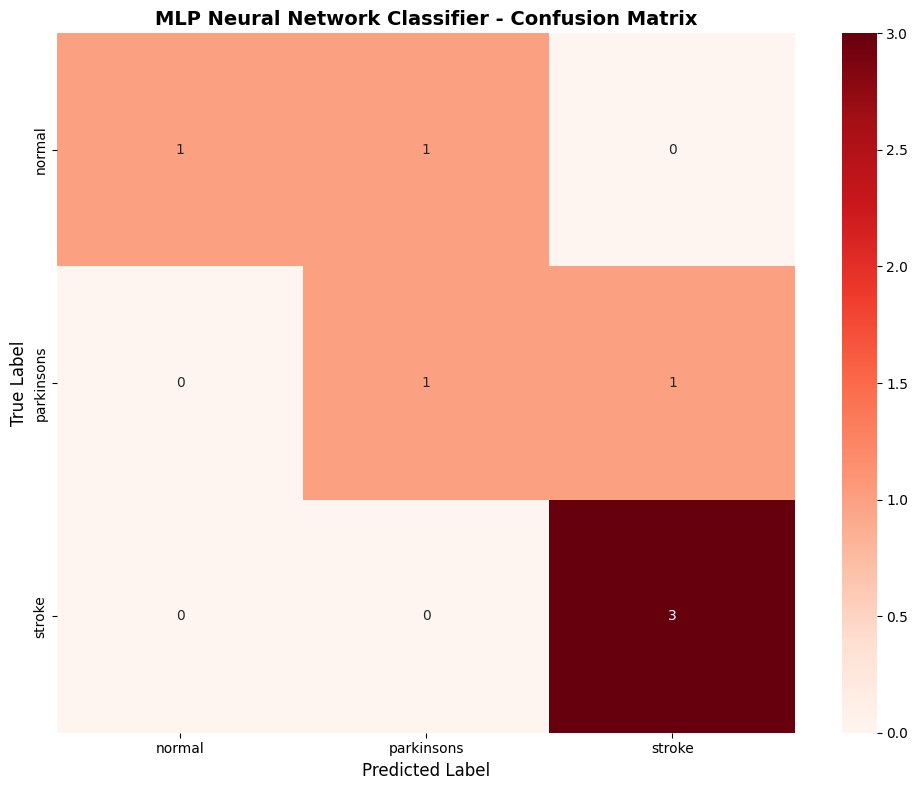


✓ MLP classifier trained and evaluated


In [58]:
# Plot MLP confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    mlp_eval_metrics['confusion_matrix'],
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=mlp_eval_metrics['classes'],
    yticklabels=mlp_eval_metrics['classes']
)
plt.title('MLP Neural Network Classifier - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print("\n✓ MLP classifier trained and evaluated")

## 14. Train & Eval Ensemble Classifier

Ensemble methods combine predictions from multiple classifiers to achieve better accuracy and robustness. The ensemble leverages the strengths of different algorithms through voting strategies.

In [59]:
from ambient.classification.ensemble_classifier import (
    EnsembleGaitClassifier,
    EnsembleClassifierConfig,
    VotingStrategy
)

# Configure Ensemble classifier
# Ensemble combines multiple classifiers to leverage their diverse strengths:
#   - KNN: Local pattern matching
#   - Random Forest: Feature interactions and robustness
#   - XGBoost: Gradient boosting for high accuracy
#   - SVM: Optimal decision boundaries
#   - Logistic: Linear relationships
#   - Decision Tree: Interpretable rules
#   - MLP: Non-linear patterns
#
# Voting strategies:
#   - HARD: Majority vote (most common prediction)
#   - SOFT: Average predicted probabilities (recommended)
#   - WEIGHTED: Weight by classifier performance
ensemble_config = EnsembleClassifierConfig(
    voting_strategy=VotingStrategy.SOFT,  # Average probabilities
    classifiers=['knn', 'rf', 'xgboost', 'svm', 'logistic', 'decisiontree', 'mlp'],
    normalize_features=True,
    random_state=42
)

ensemble_classifier = EnsembleGaitClassifier(ensemble_config)
print("✓ Ensemble classifier created with 7 base classifiers")

2026-01-22 12:17:49.738 | INFO     | ambient.classification.knn_classifier:__init__:238 - KNN classifier initialized with k=5
2026-01-22 12:17:49.738 | INFO     | ambient.classification.ensemble_classifier:_initialize_classifiers:134 - Initialized knn classifier
2026-01-22 12:17:49.738 | INFO     | ambient.classification.rf_classifier:__init__:141 - Random Forest classifier initialized with 100 trees
2026-01-22 12:17:49.738 | INFO     | ambient.classification.ensemble_classifier:_initialize_classifiers:134 - Initialized rf classifier
2026-01-22 12:17:49.739 | INFO     | ambient.classification.xgboost_classifier:__init__:85 - XGBoost classifier initialized with 100 estimators
2026-01-22 12:17:49.739 | INFO     | ambient.classification.ensemble_classifier:_initialize_classifiers:134 - Initialized xgboost classifier
2026-01-22 12:17:49.739 | INFO     | ambient.classification.svm_classifier:__init__:77 - SVM classifier initialized with rbf kernel, C=1.0
2026-01-22 12:17:49.739 | INFO     |

✓ Ensemble classifier created with 7 base classifiers


In [60]:
# Train Ensemble classifier (trains all base classifiers)
ensemble_metrics = ensemble_classifier.train(train_features, validate=True)

# Display training results
print("\n" + "="*70)
print("ENSEMBLE CLASSIFIER TRAINING RESULTS")
print("="*70)
print(f"Number of Samples:     {ensemble_metrics['n_samples']}")
print(f"Number of Classifiers: {ensemble_metrics['n_classifiers']}")
print(f"Voting Strategy:       {ensemble_metrics['voting_strategy']}")

print("Individual Classifier Performance:")
for clf_name, clf_metrics in ensemble_metrics['classifiers'].items():
    if 'train_accuracy' in clf_metrics:
        acc = clf_metrics['train_accuracy']
        weight = ensemble_metrics['ensemble_weights'].get(clf_name, 0)
        print(f"  {clf_name:15s}: {acc:.3f} (weight: {weight:.3f})")
    elif 'error' in clf_metrics:
        print(f"  {clf_name:15s}: FAILED - {clf_metrics['error']}")

print("="*70)

2026-01-22 12:17:49.747 | INFO     | ambient.classification.ensemble_classifier:train:161 - Training ensemble with 26 samples
2026-01-22 12:17:49.747 | INFO     | ambient.classification.ensemble_classifier:train:171 - Training knn...
2026-01-22 12:17:49.747 | INFO     | ambient.classification.knn_classifier:train:267 - Training KNN classifier with 26 samples
2026-01-22 12:17:49.748 | INFO     | ambient.classification.knn_classifier:train:268 - Feature shape: (26, 15)
2026-01-22 12:17:49.748 | INFO     | ambient.classification.knn_classifier:train:269 - Classes: ['normal' 'parkinsons' 'stroke']
2026-01-22 12:17:49.749 | INFO     | ambient.classification.knn_classifier:train:274 - Features normalized using StandardScaler
2026-01-22 12:17:49.756 | INFO     | ambient.classification.knn_classifier:train:298 - Cross-validation accuracy: 0.580 ± 0.133
2026-01-22 12:17:49.757 | INFO     | ambient.classification.knn_classifier:train:302 - Training complete. Accuracy: 1.000
2026-01-22 12:17:49.7


ENSEMBLE CLASSIFIER TRAINING RESULTS
Number of Samples:     26
Number of Classifiers: 7
Voting Strategy:       soft
Individual Classifier Performance:
  knn            : 1.000 (weight: 1.000)
  rf             : 1.000 (weight: 1.000)
  xgboost        : 1.000 (weight: 1.000)
  svm            : 0.885 (weight: 0.885)
  logistic       : 0.923 (weight: 0.923)
  decisiontree   : 1.000 (weight: 1.000)
  mlp            : 1.000 (weight: 1.000)


In [61]:
# Evaluate Ensemble on test set
ensemble_eval = ensemble_classifier.evaluate(test_features)

print("\n" + "="*70)
print("ENSEMBLE TEST RESULTS")
print("="*70)
print(f"Ensemble Accuracy: {ensemble_eval['ensemble']['accuracy']:.3f}")
print(f"Ensemble F1 Score: {ensemble_eval['ensemble']['f1_score']:.3f}")

print("\nIndividual Classifier Test Accuracy:")
for clf_name, clf_metrics in ensemble_eval['individual_classifiers'].items():
    if 'accuracy' in clf_metrics:
        print(f"  {clf_name:15s}: {clf_metrics['accuracy']:.3f}")

print("\nEnsemble Classification Report:")
ensemble_report = ensemble_eval['ensemble']['classification_report']
for class_name in ensemble_eval['ensemble']['classification_report'].keys():
    if class_name not in ['accuracy', 'macro avg', 'weighted avg']:
        cm = ensemble_report[class_name]
        print(f"\n{class_name}:")
        print(f"  Precision: {cm['precision']:.3f}")
        print(f"  Recall: {cm['recall']:.3f}")
        print(f"  F1-Score: {cm['f1-score']:.3f}")

print("="*70)

2026-01-22 12:17:50.415 | INFO     | ambient.classification.knn_classifier:classify_gait:367 - Classification: stroke (confidence: 0.831)
2026-01-22 12:17:50.448 | INFO     | ambient.classification.rf_classifier:classify_gait:303 - Classification: stroke (confidence: 0.760)
2026-01-22 12:17:50.450 | INFO     | ambient.classification.base_classifier:classify_gait:231 - Classification: stroke (confidence: 0.778)
2026-01-22 12:17:50.451 | INFO     | ambient.classification.base_classifier:classify_gait:231 - Classification: stroke (confidence: 0.320)
2026-01-22 12:17:50.451 | INFO     | ambient.classification.base_classifier:classify_gait:231 - Classification: normal (confidence: 0.431)
2026-01-22 12:17:50.452 | INFO     | ambient.classification.base_classifier:classify_gait:231 - Classification: stroke (confidence: 1.000)
2026-01-22 12:17:50.452 | INFO     | ambient.classification.base_classifier:classify_gait:231 - Classification: stroke (confidence: 0.902)
2026-01-22 12:17:50.453 | INFO


ENSEMBLE TEST RESULTS
Ensemble Accuracy: 0.571
Ensemble F1 Score: 0.444

Individual Classifier Test Accuracy:
  rf             : 0.571
  xgboost        : 0.571
  svm            : 0.714
  logistic       : 0.429
  decisiontree   : 0.429
  mlp            : 0.429

Ensemble Classification Report:

normal:
  Precision: 0.500
  Recall: 1.000
  F1-Score: 0.667

parkinsons:
  Precision: 0.000
  Recall: 0.000
  F1-Score: 0.000

stroke:
  Precision: 0.667
  Recall: 0.667
  F1-Score: 0.667


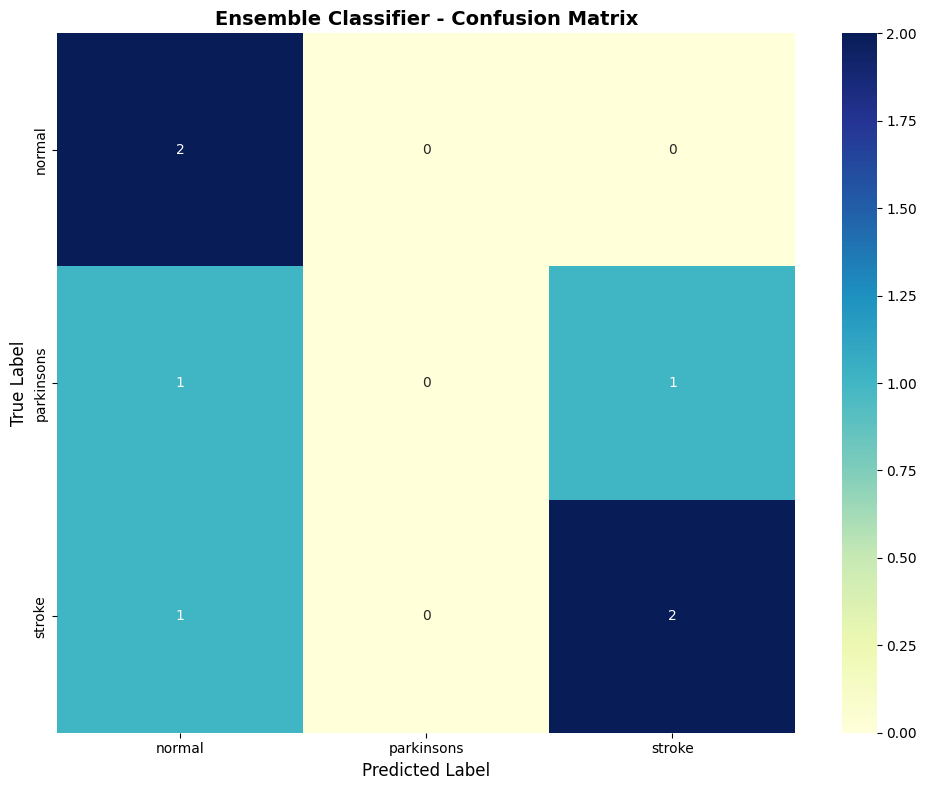


✓ Ensemble classifier trained and evaluated


In [62]:
# Plot Ensemble confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    ensemble_eval['ensemble']['confusion_matrix'],
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    xticklabels=eval_metrics['classes'],
    yticklabels=eval_metrics['classes']
)
plt.title('Ensemble Classifier - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print("\n✓ Ensemble classifier trained and evaluated")

## 15. Comprehensive Classifier Performance Comparison

Let's compare the performance of all classifiers side by side, including:
- KNN (K-Nearest Neighbors)
- Random Forest
- SVM (Support Vector Machine)
- XGBoost (Gradient Boosting)
- Decision Tree
- Logistic Regression
- MLP (Neural Network)
- Ensemble (Combined)

In [63]:
# Collect all evaluation metrics
all_classifiers = {
    'KNN': eval_metrics,
    'Random Forest': eval_metrics,  # From section 7
    'SVM': svm_eval_metrics,
    'XGBoost': xgb_eval_metrics,
    'Decision Tree': dt_eval_metrics,
    'Logistic Regression': logistic_eval_metrics,
    'MLP': mlp_eval_metrics,
    'Ensemble': ensemble_eval['ensemble']
}

# Create comprehensive comparison DataFrame
comparison_data = {
    'Classifier': [],
    'Test Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1 Score': []
}

for clf_name, clf_metrics in all_classifiers.items():
    comparison_data['Classifier'].append(clf_name)
    comparison_data['Test Accuracy'].append(clf_metrics['accuracy'])
    comparison_data['Precision'].append(clf_metrics['precision'])
    comparison_data['Recall'].append(clf_metrics['recall'])
    comparison_data['F1 Score'].append(clf_metrics['f1_score'])

df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.sort_values('Test Accuracy', ascending=False)

print("\n" + "="*80)
print("COMPREHENSIVE CLASSIFIER PERFORMANCE COMPARISON")
print("="*80)
print(df_comparison.to_string(index=False, float_format=lambda x: f'{x:.3f}'))
print("="*80)

# Find best classifier
best_clf = df_comparison.iloc[0]['Classifier']
best_acc = df_comparison.iloc[0]['Test Accuracy']
print(f"\n🏆 Best Classifier: {best_clf} (Accuracy: {best_acc:.3f})")


COMPREHENSIVE CLASSIFIER PERFORMANCE COMPARISON
         Classifier  Test Accuracy  Precision  Recall  F1 Score
                MLP          0.714      0.750   0.667     0.675
                KNN          0.571      0.389   0.556     0.444
      Random Forest          0.571      0.389   0.556     0.444
                SVM          0.571      0.556   0.556     0.556
            XGBoost          0.571      0.389   0.556     0.444
           Ensemble          0.571      0.389   0.556     0.444
Logistic Regression          0.429      0.444   0.444     0.433
      Decision Tree          0.286      0.278   0.278     0.267

🏆 Best Classifier: MLP (Accuracy: 0.714)


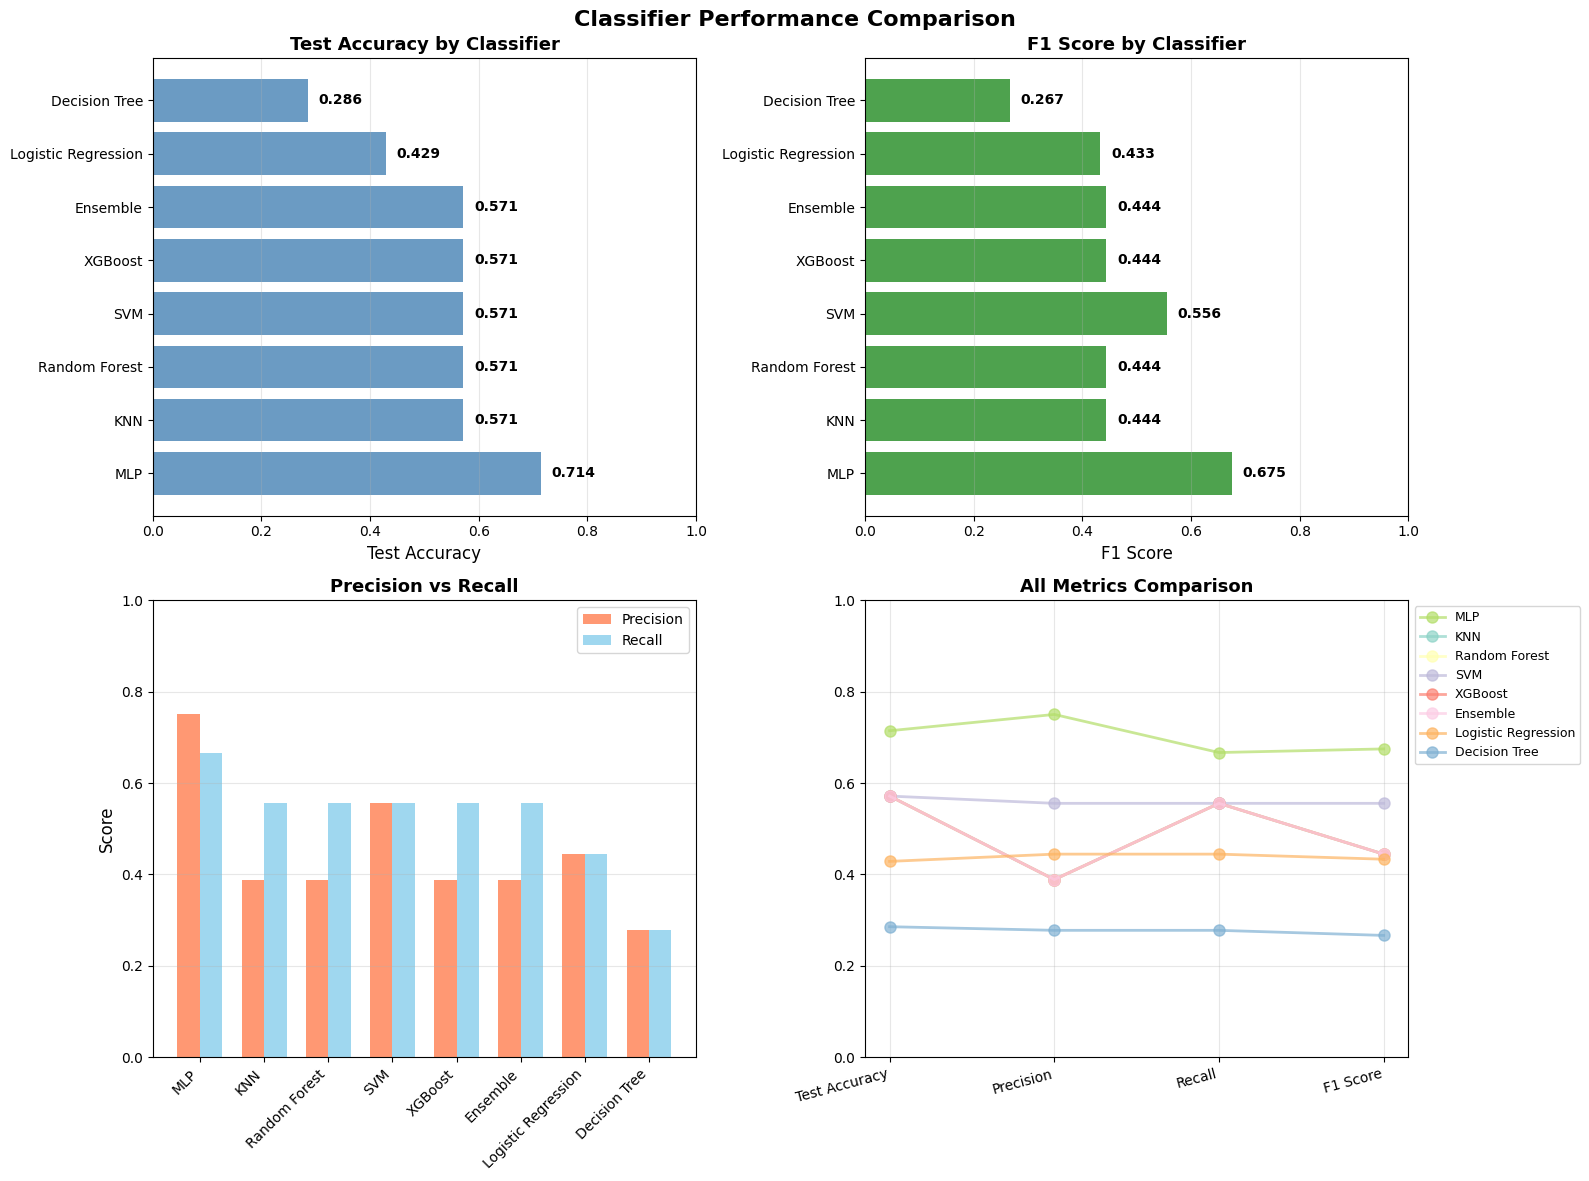

In [64]:
# Visualize overall performance comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Classifier Performance Comparison', fontsize=16, fontweight='bold')

# 1. Test Accuracy Comparison
ax1 = axes[0, 0]
bars1 = ax1.barh(df_comparison['Classifier'], df_comparison['Test Accuracy'], 
                 color='steelblue', alpha=0.8)
ax1.set_xlabel('Test Accuracy', fontsize=12)
ax1.set_title('Test Accuracy by Classifier', fontsize=13, fontweight='bold')
ax1.set_xlim([0, 1.0])
ax1.grid(axis='x', alpha=0.3)
# Add value labels
for i, (bar, val) in enumerate(zip(bars1, df_comparison['Test Accuracy'])):
    ax1.text(val + 0.02, i, f'{val:.3f}', va='center', fontweight='bold')

# 2. F1 Score Comparison
ax2 = axes[0, 1]
bars2 = ax2.barh(df_comparison['Classifier'], df_comparison['F1 Score'], 
                 color='forestgreen', alpha=0.8)
ax2.set_xlabel('F1 Score', fontsize=12)
ax2.set_title('F1 Score by Classifier', fontsize=13, fontweight='bold')
ax2.set_xlim([0, 1.0])
ax2.grid(axis='x', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars2, df_comparison['F1 Score'])):
    ax2.text(val + 0.02, i, f'{val:.3f}', va='center', fontweight='bold')

# 3. Precision vs Recall
ax3 = axes[1, 0]
x = range(len(df_comparison))
width = 0.35
ax3.bar([i - width/2 for i in x], df_comparison['Precision'], width, 
        label='Precision', color='coral', alpha=0.8)
ax3.bar([i + width/2 for i in x], df_comparison['Recall'], width, 
        label='Recall', color='skyblue', alpha=0.8)
ax3.set_ylabel('Score', fontsize=12)
ax3.set_title('Precision vs Recall', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(df_comparison['Classifier'], rotation=45, ha='right')
ax3.legend()
ax3.set_ylim([0, 1.0])
ax3.grid(axis='y', alpha=0.3)

# 4. All Metrics Radar Chart
ax4 = axes[1, 1]
metrics_to_plot = ['Test Accuracy', 'Precision', 'Recall', 'F1 Score']
colors = plt.cm.Set3(range(len(df_comparison)))
for idx, row in df_comparison.iterrows():
    values = [row[m] for m in metrics_to_plot]
    ax4.plot(metrics_to_plot, values, 'o-', label=row['Classifier'], 
             color=colors[idx], linewidth=2, markersize=8, alpha=0.7)
ax4.set_ylim([0, 1.0])
ax4.set_title('All Metrics Comparison', fontsize=13, fontweight='bold')
ax4.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=9)
ax4.grid(True, alpha=0.3)
ax4.set_xticklabels(metrics_to_plot, rotation=15, ha='right')

plt.tight_layout()
plt.show()

In [65]:
# Per-class performance comparison
print("\n" + "="*80)
print("PER-CLASS PERFORMANCE COMPARISON")
print("="*80)

# Get all unique classes
classes = eval_metrics['classes']

for class_name in classes:
    print(f"\n{class_name.upper()}:")
    print("-" * 80)
    print(f"{'Classifier':<20} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
    print("-" * 80)
    
    for clf_name, clf_metrics in all_classifiers.items():
        report = clf_metrics['classification_report']
        if class_name in report:
            cm = report[class_name]
            print(f"{clf_name:<20} {cm['precision']:>10.3f} {cm['recall']:>10.3f} "
                  f"{cm['f1-score']:>10.3f}")

print("="*80)


PER-CLASS PERFORMANCE COMPARISON

NORMAL:
--------------------------------------------------------------------------------
Classifier            Precision     Recall   F1-Score
--------------------------------------------------------------------------------
KNN                       0.500      1.000      0.667
Random Forest             0.500      1.000      0.667
SVM                       0.500      0.500      0.500
XGBoost                   0.500      1.000      0.667
Decision Tree             0.333      0.500      0.400
Logistic Regression       0.333      0.500      0.400
MLP                       1.000      0.500      0.667
Ensemble                  0.500      1.000      0.667

PARKINSONS:
--------------------------------------------------------------------------------
Classifier            Precision     Recall   F1-Score
--------------------------------------------------------------------------------
KNN                       0.000      0.000      0.000
Random Forest             

In [66]:
# Statistical summary
print("\n" + "="*80)
print("STATISTICAL SUMMARY")
print("="*80)

summary_stats = df_comparison[['Test Accuracy', 'Precision', 'Recall', 'F1 Score']].describe()
print(summary_stats.to_string(float_format=lambda x: f'{x:.3f}'))

print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)

# Best performers
best_accuracy = df_comparison.loc[df_comparison['Test Accuracy'].idxmax()]
best_f1 = df_comparison.loc[df_comparison['F1 Score'].idxmax()]
best_precision = df_comparison.loc[df_comparison['Precision'].idxmax()]
best_recall = df_comparison.loc[df_comparison['Recall'].idxmax()]

print(f"🎯 Highest Accuracy:  {best_accuracy['Classifier']} ({best_accuracy['Test Accuracy']:.3f})")
print(f"🎯 Highest F1 Score:  {best_f1['Classifier']} ({best_f1['F1 Score']:.3f})")
print(f"🎯 Highest Precision: {best_precision['Classifier']} ({best_precision['Precision']:.3f})")
print(f"🎯 Highest Recall:    {best_recall['Classifier']} ({best_recall['Recall']:.3f})")

# Performance spread
acc_range = df_comparison['Test Accuracy'].max() - df_comparison['Test Accuracy'].min()
print(f"\n📊 Accuracy Range: {acc_range:.3f} "
      f"(from {df_comparison['Test Accuracy'].min():.3f} to {df_comparison['Test Accuracy'].max():.3f})")

# Recommendations
print("\n💡 RECOMMENDATIONS:")
if best_accuracy['Classifier'] == 'Ensemble':
    print("   ✓ Ensemble achieves best performance by combining multiple models")
else:
    print(f"   ✓ {best_accuracy['Classifier']} performs best for this dataset")
    print(f"   ✓ Consider using Ensemble for production (robustness)")

if acc_range < 0.1:
    print("   ✓ All classifiers perform similarly - choose based on interpretability/speed")
else:
    print("   ✓ Significant performance differences - model selection is important")

print("\n✓ Classifier comparison complete")
print("="*80)


STATISTICAL SUMMARY
       Test Accuracy  Precision  Recall  F1 Score
count          8.000      8.000   8.000     8.000
mean           0.536      0.448   0.521     0.463
std            0.127      0.144   0.115     0.116
min            0.286      0.278   0.278     0.267
25%            0.536      0.389   0.528     0.442
50%            0.571      0.389   0.556     0.444
75%            0.571      0.472   0.556     0.472
max            0.714      0.750   0.667     0.675

KEY INSIGHTS
🎯 Highest Accuracy:  MLP (0.714)
🎯 Highest F1 Score:  MLP (0.675)
🎯 Highest Precision: MLP (0.750)
🎯 Highest Recall:    MLP (0.667)

📊 Accuracy Range: 0.429 (from 0.286 to 0.714)

💡 RECOMMENDATIONS:
   ✓ MLP performs best for this dataset
   ✓ Consider using Ensemble for production (robustness)
   ✓ Significant performance differences - model selection is important

✓ Classifier comparison complete
